In [1]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# CCAI Tutorial: Agile Modeling for Bioacoustic Monitoring

Authors (Equal Contribution):
*   Jenny Hamer, Google DeepMind, hamer@google.com
*   Rob Laber, Google Cloud, roblaber@google.com
*   Tom Denton, Google Research, tomdenton@google.com

Revised for CCAI Virtual Summer School 2026:
*   Tariq Shahzad, COMSATS University Islamabad

An interactive tutorial (requires user engagement) that demonstrates analyzing an unlabeled bioacoustic dataset for a target species given a vocalization of that species to help provide insights for ecologists, conservationists, land managers, and other domain experts. We achieve this by leveraging a [high-quality, bioacoustic pre-trained model](https://tfhub.dev/google/bird-vocalization-classifier/4), searching over the unlabeled corpus conditioned on a single species example, and applying an efficient ML technique to produce matches.

Originally created as tutorial at NeurIPS 2023 Workshop [Tackling Climate Change with ML](https://nips.cc/virtual/2023/workshop/66543). View the poster [here](https://drive.google.com/file/d/1-FHYqaY4Y0vA0P3lvcyINFDFlKWuKMw4/view?usp=drive_link).

# Table of Contents


<!-- *   [Data Hosting & Package Installs](#data-installs) -->
*   [Overview](#overview)
  - [Glossary](#glossary)
  - [Bioacoustics and Biodiversity](#bio_and_bio)
  - [Agile Modeling for Bioacoustics](#agile_modeling)
*   [Climate Impact](#climate-impact)
*   [Target Audience](#target-audience)
*   [Data Description](#data-description)
*   [Methodology](#methodology)
  - [Software Requirements](#software-requirements)
  - [Embed the Search Dataset](#embed_data)
  - [Audio Similarity Search](#similarity-search)
  - [Active Learning](#active-learning)
*   [Discussion](#discussion)
*   [References](#references)


<a name="overview"></a>
# Overview

The goal of this tutorial is to demonstrate the use of an **active learning** technique to produce an audio classifier for a novel task.

At a high level, active learning (aka "agile modeling") can be described as the process of bootstrapping dataset annotation by making use of an existing model, and then training a new classifier based on the bootstrapped dataset. The technique relies on a **human-in-the-loop workflow** to extract and produce a small subset of annotated data from the unlabeled dataset, which can then be used as training data for downstream tasks. Our workflow is particularly useful in situations where:
* You would like to generate a custom classification model for a specialized task where you may not have enough labeled data to train a model from scratch
* You have access to an existing model (or dataset to train a model) that performs an adjacent task.

<a name=glossary></a>
## Glossary

We provide a high-level, intuitive description of some of the core machine learning concepts utilized and presented in this tutorial.

### Agile Modeling

Agile modeling in the context of supervised machine learning can be described as “the process of turning any subjective visual concept into a computer vision model through real-time user-in-the-loop interactions” ([Stretcu et al. 2023](https://arxiv.org/abs/2302.12948)). In our setting, we go beyond the typical image and computer vision settings to explore the audio domain, where **we transform a single labeled audio sample of a species vocalization into a bioacoustic classifier.**



### Transfer Learning

Transfer learning is a technique that relies on the reuse of a pre-trained model on a new task (different dataset from which it was trained). This technique assumes that the pre-training of the model produces a useful representation and knowledge that can be extended to the new task/setting. In the context of this tutorial, we use a model pre-trained on a large acoustic dataset of bird vocalizations (Xeno-Canto, focal recordings) to produce embeddings of a new soundscape dataset (passive recordings).


**Intuition:** in the context of avian bioacoustics, transfer learning is useful for building a general representation that can translate to specific species or geographical regions, particularly when labeled data is scarcer. Using a pre-trained model with transfer learning lowers the machine learning overhead for field experts and practitioners who seek to understand and interpret unlabeled data, such as that from passive acoustic monitoring (PAM).

### Active Learning

Active Learning is a general term for an iterative, supervised ML technique that efficiently makes use of labeled data to “learn the labels” or classify unlabeled data. This learning setting is particularly helpful in scenarios where unlabeled data is abundant and producing labels for that data is costly, requires expert knowledge, lots of manual work, etc.

### Embeddings

At their core, neural networks function by learning new representations of data that help make the underlying patterns in the dataset more obvious.  These representations are called **embeddings**.  Concretely, an embedding is a point (or vector) in a high dimensional space.  Data points with embeddings that are close to each other are likely to share salient traits.

<a name=bio_and_bio></a>

## Bioacoustics and Biodiversity

Listening is a fantastic way to understand an ecosystem. An extremely broad collection of animals use sound to communicate--from owls to orcas, from bats to bonobos--which provides us with the opportunity to listen in and learn what animals are in an ecosystem.

We can also learn about the relationships between different animals: alarm calls indicate the presence of silent predators, and can even [contain clues about what kinds of predators are nearby](https://www.washington.edu/news/2005/06/23/chickadees-alarm-calls-carry-information-about-size-threat-of-predator/). We can measure how vocalizations change in response to differences in the natural environment (elevation, temperature, [geographic location](https://www.smithsonianmag.com/science-nature/do-birds-have-language-180979629), seasonality) or in response to human interventions (restoration programs, logging, proximity to highways, etc.).

The insights we gain from bioacoustic analysis can help understand the impact of interventions, and inform decisions for conservation. Bioacoutics is actively used for:
* [Finding, tracking, and protecting threatened and endangered species](https://www.birds.cornell.edu/ccb/picking-up-good-vibrations-for-elephant-conservation/)
* [Quantifying broad biodiversity](https://academic.oup.com/condor/article/124/2/duac003/6572065)
* [Understanding species population health](https://conbio.onlinelibrary.wiley.com/doi/10.1111/csp2.72)
* [Understanding ecosystem health](https://www.frontiersin.org/articles/10.3389/fevo.2021.706445/full)
* [Identifying destructive+illegal human activities](https://www.fastcompany.com/90435386/this-network-of-microphones-listens-for-the-chainsaws-of-illegal-loggers-in-the-rainforest)
* [Early detection and response to invasive species](https://connormwood.com/spotted-owl-conservation/)

...and more! Projecting forward, we also expect bioacoustics to play an increasing role in the assessment of areas to protect for the [30-by-30](https://en.wikipedia.org/wiki/30_by_30) initiative, as well as in assessments for [biodiversity credits](https://www.weforum.org/agenda/2022/12/biodiversity-credits-nature-cop15/) and [corporate responsibility initiatives](https://www.sustainability.nespresso.com/birdsong-sound-of-sustainability).

Thanks to the broad range of vital applications and wide availability of cheap recording devices, bioacoustic surveys are steadily growing in size and scope: [one ongoing study](https://www.damonlesmeister.com/pnw-bioacoustics.html) in the Northwestern US deployed over 5,000 microphones in the summer of 2023. Meanwhile, the [Australian Acoustic Observatory](https://acousticobservatory.org/) has collected over 2 million hours of audio from across the continent in just a couple years since its launch. And there are massive efforts to monitor marine mammals and coral reefs: the [SanctSound](https://www.ncei.noaa.gov/news/sanctsound-studying-underwater-world-sound) project gathered over 500TB of data between 2018 and 2022.

**However, there are challenges!**

Bioacoustic surveys can generate thousands or even millions of hours of audio, far more than experts could ever listen to. As a result, we require machine learning tools which mulitply the efforts of these experts. These tools must also allow us to work with staggering amounts of audio data efficiently.

Additionally, new problems are appearing all the time: no single classifier is going to cover all the bases. There are thousands of species for which we don't have sufficient training data for traditional ML classifier training, especially in tropical areas where biodiversity is the greatest. Furthermore, we are often concerned with different types of vocalizations. If we can differentiate between juvenile and adult calls, we can measure a population's reproductive health efficiently. In other cases, different calls can help determine if an endangered species is nesting in an area (requiring a high degree of protection) or simply passing through the area. Needless to say, training data for these highly-specific problems often simply does not exist.

As a result, training a single mega-classifier is not enough: We require flexible tooling which can capture new kinds of insights efficiently.


<a name=agile_modeling></a>
## Agile Modeling for Bioacoustics

The core problem this tutorial addresses lies in biodiversity monitoring using large-scale, unlabeled audio data, as collected by inexpensive passive acoustic monitoring (PAM) devices. We present an **integrated workflow** for analyzing large unlabeled bioacoustic datasets, adapting new [agile modeling techniques](https://arxiv.org/abs/2302.12948) to the audio domain. The tools we provide enable users to adapt a classifier for a novel class (species, specific call type, etc...) with minimal overhead.

Our goal is to **allow experts to create classifiers for new sounds in less than an hour.**

The overall flow has three main parts:
* First, we use a high-quality *embedding model* to produce embeddings of a large unlabeled dataset, such as a conservation organization might collect. This produces a large table of embeddings, which can be easily joined back to the original audio. (For large datasets, this step may take a substantial amount of time, but only needs to be done once: All later steps make use of these precomputed embeddings.)

* Next, we use audio similarity search to sift through the unlabeled dataset embeddings for sounds of interest. The user provides a query—an example of a sound category they are searching for, like a juvenile call for a particular species—which is also embedded, and we present the user with the most relevant dataset elements according to their embeddings' similarity to the query embedding. The user marks the retrieved dataset elements as relevant or irrelevant, which provides training data for the next step.
   
  - The similarity search over embeddings allows us to find similar audio examples, even when there is some variation, vocalizations are quiet, or there are overlapping sounds.
  
  - In the example below, we are able to find relevant examples of hairy woodpecker drumming sounds (blue) even in the presence of competing sounds (brown).  The [spectrogram](https://en.wikipedia.org/wiki/Spectrogram) on the left is a known
  vocalization of a hairy woodpecker.  The similarity search algorithm allows us to detect instances of this vocalizations in an audio context that may have
  other background noise (the three spectrograms on the right, with background noise indicated in brown):
  > ![search](https://docs.google.com/drawings/d/e/2PACX-1vSIwCEkHNEjtyh3PLhTa-4hTTaBoMnWGVXobr91rKeD7m52a4ES9K0JZ_tqltasUWctgLHnf2PrvtKU/pub?w=371&h=253)
  


* The final step is to use the training data obtained in the previous step as part of an active learning loop to train a classifier for the user's search query. During each iteration of the loop, we fit a simple classifier onto the training data. We use the trained classifier along with margin sampling to efficiently surface 'hard' examples that are then rated by the user as relevant or irrelevant to their query. Finally, the newly-rated data is added to the training data for the next iteration of the active learning loop. The fact that embeddings are only computed once on the unlabeled dataset means that each iteration of the loop is very fast to carry out.

The core of this process is a high-quality model for bioacoustic data. [We have shown](https://arxiv.org/pdf/2307.06292.pdf) that the embeddings from our [global bird classification model](https://tfhub.dev/google/bird-vocalization-classifier/4) transfer efficiently to novel bioacoustic problems - including bird call-types, bats, and marine mammals - outperforming general audio foundation models. Additionally, because we work with precomputed embeddings, the classifiers are very quick to train and to apply to the unlabeled dataset.

For example, here's a t-SNE projection of embeddings from a call-type dataset with five classes (each color corresponds to a single class). On this dataset, we can exceed 0.95 ROC-AUC using only four training examples per class, significantly outperforming AudioMAE, YamNet, and VGGish.

> ![search](https://drive.google.com/uc?id=1w2z-WlVtR2k2tNxzgb174O1QIp96nW81)

This well-separated embedding space lends itself to classification in novel bioacoustic tasks, and is also excellent for audio similarity search.

<a name="climate-impact"></a>
# Climate Impact

As climate change rapidly alters short-term weather patterns and longer-term trajectories – along with contributing to more widespread and frequent extreme weather events – these changes can significantly harm natural ecosystems, habitats, and the species that call them home, endangering biodiversity. According to the [California Dept. of Fish and Wildlife](https://wildlife.ca.gov/Science-Institute/Climate-Biodiversity-Monitoring), studying biodiversity can provide insights into potential links between climate change and its effects on local ecosystems and species. Beyond the increased understanding into the current state of climate change, these insights can help inform on-going and future risks to local species, biodiversity, and adaptive decision-making for species protection and land management.

Some studies have found that healthy ecosystems better suppress carbon. As an example, recent work from [Pearson et al. 2022, University of Alaska Southeast](https://www.cell.com/trends/ecology-evolution/fulltext/S0169-5347(22)00279-8) indicates that restoring whale populations will enhance carbon storage in whale biomass and carbon sequestration via nutrient provisioning.

The [rising temperatures in Hawaii](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5218566/#:~:text=Avian%20malaria%20is%20strongly%20influenced,potential%20extinction%20of%20highly%20susceptible) have allowed invasive mosquitos to encroach on the remaining natural habitat of native birds susceptible to avian malaria, highlighting the complexity of the biodiversity and climate change relationship.

<a name=target-audience></a>
# Target Audience

This tutorial is designed to serve two main audiences:
* ML practitioners interested in exploring the application of ML techniques to problems related to bioacoustics and biodiversity monitoring.
* Field experts in areas such as ecology, land management, biodiversity monitoring, ornithology, etc. with some basic background in machine learning seeking new tools to process bioacoustic datasets given known species of interest.

<a name="data-description"></a>
# Data Description

The main goal of this notebook is to demonstrate the Active Learning technique.  In order to best illustrate the technique, we will use some specific datasets that are tailored to a specific goal.  However, we encourage the reader to keep in mind that the specifics of the dataset(s) and our chosen Machine Learning goal in this notebook are just for illustrative purposes.  The Active Learning technique is broadly applicable for analysis of novel datasets across diverse domains and fields.

In this tutorial we will use two datasets.  The first, [Xeno Canto](https://xeno-canto.org/), is a large, open source, annotated corpus of thousands of audio samples covering a broad swath of the global avian species.  This dataset was used to train a bird classier that predicts a species for a given vocalization.  We highlight that this model was trained without any specific learning task in mind (beyond the generic species classification).  This model is used to generate the embeddings that were discussed above.


The second dataset is called [Powdermill](https://zenodo.org/record/4656848#.Y7ijhOxudhE).  It is an open-sourced, **soundscape** (ie, passively recorded) dataset collected from the Powdermill Nature Reserve in Pennsylvania, USA, consisting of many hours of **unlabeled** audio recordings containing high activity "dawn chorus" avian vocalizations.

The goal of this tutorial is to show how to use the general purpose bird classifier model (trained on Xeno Canto) to analyze a novel unlabeled audio corpus.

<a name="methodology"></a>
# Methodology

This section contains the main content of this notebook.

As mentioned above, the goal of this notebook is to demonstrate the Active Learning technique to analyze unlabeled acoustic datasets.  **To illustrate the technique, we will play the role of an ecologist seeking to understand vocalization patterns of a specific species, the [Wood Thrush](https://ebird.org/species/woothr) (_Hylocichla mustelina_), in the Powdermill Nature Reserve in the eastern United States.**  In particular, we have *hundreds of hours* of audio data collected from the Powdermill Nature Reserve, and we want to know how many Wood Thrush vocalizations we can detect. Sorting through all of this audio manually would take weeks or months.

![wood_thrush](https://drive.google.com/uc?id=106SGB3utHbknocxFs3zBVRrnSQn-3SCC)
**A Wood Thrush.**

Medium-sized thrush with a large, round white belly covered in brown spots. Sings a flutelike clear song from understory and canopy perches.
(Image source: All About Birds [Macaulay Library photogallery](https://www.allaboutbirds.org/guide/Wood_Thrush/photo-gallery/170865401))



## Overview

Our method performs a **vector search**: given a **labeled** vocalization which we'll refer to as a **query** (an audio clip with a known species vocalizing), an unlabeled audio dataset which we'll refer to as our **search corpus** (in our case, a soundscape dataset from the Powdermill Nature Reserve), slice up the search corpus into a collection of clips and search over that corpus to find "matches" with the query.

To do this, we'll follow theses high level steps:

**Step 1:** Use the generic "off the shelf" bird classification model to generate embeddings for the unlabeled **search corpus** (ie the Powdermill dataset).

**Step 2:** Obtain one or two **query** samples, which are labeled samples of the target species (in our case, the Wood Thrush). We can find known audio samples of the Wood Thrush in Cornell's [eBird dataset](https://ebird.org/species/woothr#:~:text=Top%20audio).

**Step 3:** Generate the embedding(s) corresponding to the query sample.

**Step 4:** Search within the set of embeddings generated from the search corpus (the raw Powdermill audio) for points that are "nearby" the embedding generated from the query sample. This yields a set of audio snippets from the Powdermill audio that should sound similar to the known Wood Thrush call.

**Step 5:** Manually audit the results of step 4. This involves listening to the samples and manually tagging them with the species that are present in that audio snippet.

--------------------
**Note:** We will repeat steps 4 and 5 until we have 20-30 samples for each species in question. We are "bootstrapping" a training set for a simple linear model.

--------------------
**Step 6:** Train a simple linear model based on the bootstrapped samples that we just generated.

At this point, we have what should be a high quality classifier that can detect the Wood Thrush in the Powdermill dataset. If our model is not performing as well as we'd like, we can continue to generate more training data by repeating steps 4 and 5, or we can also use our linear model to surface new points.



This section is broken down into the following parts:
*    [Setup and Configuration](#pipeline-config)
*    [Generate Embeddings](#embed_data) (Steps 1, 2, and 3)
*    [Audio Similarity Search](#similarity-search) (Steps 4 and 5)
*    [Train a Linear Classifier](#active-learning) (Step 6)



<a name="software-requirements"></a>
## Software Requirements

This tutorial runs on the free [Google Colab](https://colab.research.google.com/) runtime. A **T4 GPU** runtime is recommended (`Runtime` → `Change runtime type` → `T4 GPU`), but it is **not required**: only the audio embedding step benefits meaningfully from a GPU, and every other step here runs comfortably on CPU.

The machine learning tooling comes from **[`perch-hoplite`](https://github.com/google-research/perch-hoplite)**, an open-source library from the Google DeepMind Perch team for storing, searching, and classifying large collections of audio embeddings.

> **A note on this tutorial's history.** The original 2023 version used the [`perch`](https://github.com/google-research/perch) repository (formerly named `chirp`). That package can no longer be installed: it requires Python 3.10–3.11 while Colab now ships Python 3.12, and its declared dependencies contradict each other. The Perch team now maintains `perch-hoplite` for exactly this workflow. If you encounter older tutorials or papers referring to `chirp` or `perch`, `perch-hoplite` is the current equivalent.

Everything you need is either installed by the cell below or already present in the Colab runtime:

* Python 3.12
* TensorFlow 2.20+
* NumPy 2.x
* `kagglehub` — downloads the pre-trained model
* `codecarbon` — measures the energy and estimated emissions of the compute we run

A pinned `requirements.txt` accompanies this notebook if you wish to reproduce the environment outside Colab.

## Install `perch-hoplite`

Run the cell below, then **restart the runtime**: `Runtime` → `Restart session`.

The restart is required because the install replaces packages that Colab has already loaded into memory. You only need to do this once per session, and you do **not** need to re-run the install cell afterwards — continue from the imports cell.

In [2]:
# @title Install the required packages {display-mode: "form"}

# `perch-hoplite` provides the agile modeling workflow used throughout this
#   tutorial: embedding audio, searching those embeddings, labeling results,
#   and training a small classifier on top of them.
# `ml-collections` provides the configuration objects perch-hoplite uses. It is
#   not always present on a fresh Colab runtime, so we install it explicitly.
# `codecarbon` measures the energy use and estimated carbon emissions of the
#   compute in this notebook. Installing it now means one restart, not two.
# Colab already supplies the compatible scientific Python stack. Avoid resolving
# dependencies for these packages here because that can upgrade shared runtime
# packages and create conflicts with unrelated preinstalled tools.
!pip install -q --no-deps git+https://github.com/google-research/perch-hoplite.git ml-collections codecarbon

print('\nInstall complete.')
print('IMPORTANT: restart the runtime now -> Runtime > Restart session')
print('Then continue from the next cell. Do not re-run this cell.\n')
print('Note: you may later see a warning that `kagglehub` is out of date.')
print('It is harmless - the model downloads correctly regardless.')


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

Install complete.
IMPORTANT: restart the runtime now -> Runtime > Restart session
Then continue from the next cell. Do not re-run this cell.

Note: you may later see a warning that `kagglehub` is out of date.
It is harmless - the model downloads correctly regardless.


In [3]:
pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load the required imports

Run this cell **after** restarting the runtime.

If you see a `ModuleNotFoundError` here, either the install cell did not finish or the runtime was not restarted. Restart the session and run this cell again — you do not need to re-install.

In [5]:
# @title Imports {vertical-output: true}

import collections
import os

from etils import epath
from IPython.display import HTML
import matplotlib.pyplot as plt
from ml_collections import config_dict
import numpy as np
import tensorflow as tf
import tqdm

# perch-hoplite: the agile modeling workflow.
from perch_hoplite.agile import audio_loader
from perch_hoplite.agile import classifier
from perch_hoplite.agile import classifier_data
from perch_hoplite.agile import colab_utils
from perch_hoplite.agile import embed
from perch_hoplite.agile import embedding_display
from perch_hoplite.agile import ingest_annotations
from perch_hoplite.agile import source_info
from perch_hoplite.db import brutalism
from perch_hoplite.db import interface
from perch_hoplite.db import score_functions
from perch_hoplite.db import search_results
from perch_hoplite.zoo import model_configs

print('TensorFlow version :', tf.__version__)
print('NumPy version      :', np.__version__)

# A GPU makes the embedding step considerably faster. Every other step in this
# tutorial is quick on CPU, so a CPU-only runtime is perfectly usable.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  print(f'GPU available      : yes ({len(gpus)} device(s))')
else:
  print('GPU available      : no (CPU only - this is fine for this tutorial)')

TensorFlow version : 2.21.0
NumPy version      : 2.5.3
GPU available      : no (CPU only - this is fine for this tutorial)


<a name="pipeline-config"></a>
## Setup and Configuration

In this section, we set the configuration parameters we'll be using to process and embed the audio data, along with input and output paths for reading in the data, pre-trained model, and writing the results we produce to file.

### Load the embedding model

`perch-hoplite` ships a set of **model presets**: named, pre-configured bioacoustic models downloaded from [Kaggle Models](https://www.kaggle.com/models) the first time you use them. Choosing a preset fixes the audio parameters below for you, so there is nothing to configure by hand.

We use **`perch_8`** — version 8 of Google's [Bird Vocalization Classifier](https://www.kaggle.com/models/google/bird-vocalization-classifier). This is the direct successor to the model used in the original version of this tutorial, and it produces embeddings with the same shape and the same audio settings.

#### The parameters a preset fixes for you

* `window_size_s` — the size in seconds of each "chunk" of audio. Each chunk is treated as a single data point. 5 seconds works well for bird vocalizations. **The model architecture depends on this value, so it cannot be changed.**

* `hop_size_s` — the offset in seconds between successive chunks, also called the model *stride*. When the hop size equals the window size, chunks do not overlap at all. A smaller hop size can catch vocalizations that straddle a window boundary, but it produces a larger embedding collection, because each instant of audio then appears in several windows. As a consequence you may need to "de-dupe" your matches.

* `sample_rate` — a uniform 32 kHz. All audio is resampled to this rate. Together with a 5 second window, this means each snippet is represented as 5 × 32,000 = 160,000 samples before embedding.

* `embedding_dim` — the length of the vector the model produces for each chunk: **1280** numbers summarizing five seconds of sound.

**A note on other models.** `perch-hoplite` can load other embedding models through the same interface — Perch 2.0, BirdNET, SurfPerch (coral reefs), humpback and multispecies-whale models, and general-audio models such as YAMNet. Like the original version, this tutorial deliberately uses a single model: embeddings from different models are not comparable, so switching models means building a **fresh database** (delete the `db_path` folder, or point it somewhere new) and re-embedding the audio. Changing the model without doing that is the most common way to break this notebook.

Swapping the model is a one-word change. That is worth remembering: if the workflow in this tutorial performs poorly on *your* species or *your* recordings, the representation — not the classifier — is often what needs to change. We return to this point in the Limitations section.

In [6]:
# @title Load the pre-trained embedding model {vertical-output: true}

# Like the original version of this tutorial, we use one model throughout:
# Perch v8, the direct successor to the v4 model the 2023 version loaded
# from TFHub. perch-hoplite also supports other embedding models (Perch 2.0,
# BirdNET, SurfPerch, ...), but embeddings from different models are not
# comparable, so each model needs its own database built from scratch.
model_choice = 'perch_8'

preset_info = model_configs.get_preset_model_config(model_choice)

print(f'Preset           : {model_choice}')
print(f'Model class key  : {preset_info.model_key}')
print(f'Embedding dim    : {preset_info.embedding_dim}')
print(f'Window size (s)  : {preset_info.model_config.window_size_s}')
print(f'Hop size (s)     : {preset_info.model_config.hop_size_s}')
print(f'Sample rate (Hz) : {preset_info.model_config.sample_rate}')

# Convenience aliases used throughout the rest of the notebook.
SAMPLE_RATE = int(preset_info.model_config.sample_rate)
WINDOW_SIZE_S = float(preset_info.model_config.window_size_s)
HOP_SIZE_S = float(preset_info.model_config.hop_size_s)

# The model is downloaded from Kaggle Models on first use, then cached for the
# rest of the session.
print('\nLoading model (the first run downloads it from Kaggle)...')
embedding_model = preset_info.load_model()

# Smoke test: embed five seconds of silence and check the output shape.
silence = np.zeros([int(SAMPLE_RATE * WINDOW_SIZE_S)], dtype=np.float32)
test_embedding = embedding_model.embed(silence).embeddings

print('Model loaded successfully.')
print(f'Test embedding shape: {test_embedding.shape} '
      f'-> {test_embedding.shape[-1]} numbers describing '
      f'{WINDOW_SIZE_S:.0f}s of audio')

Preset           : perch_8
Model class key  : taxonomy_model_tf
Embedding dim    : 1280
Window size (s)  : 5.0
Hop size (s)     : 5.0
Sample rate (Hz) : 32000

Loading model (the first run downloads it from Kaggle)...


100%|██████████| 26.0/26.0 [00:00<00:00, 33.8kB/s]


100%|██████████| 8.21k/8.21k [00:00<00:00, 14.4MB/s]

  0%|          | 0.00/3.28k [00:00<?, ?B/s]






100%|██████████| 3.28k/3.28k [00:00<00:00, 740kB/s]
100%|██████████| 26.6k/26.6k [00:00<00:00, 1.19MB/s]



100%|██████████| 658/658 [00:00<00:00, 267kB/s]



100%|██████████| 95.0k/95.0k [00:00<00:00, 413kB/s]












100%|██████████| 3.70M/3.70M [00:00<00:00, 4.58MB/s]


































































100%|██████████| 91.4M/91.4M [00:03<00:00, 25.9MB/s]
/Users/juliagonzalez/bioacoustic-monitoring/.venv/lib/python3.12/site-packages/perch_hoplite/zoo/zoo_interface.py:159: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  framed_audio = np.divide(framed_audio, peak_norm, where=(peak_norm > 0.0))
I0000 00:00:1789411852.378287 3669144 service.cc:153] XLA service 0x30a8cb970 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789411852.378485 3669144 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1789411852.573676 3669144 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPROD

Model loaded successfully.
Test embedding shape: (1, 1, 1280) -> 1280 numbers describing 5s of audio


#### Optional: load a prepared database (classrooms)

The 2023 version of this tutorial distributed **pre-computed embeddings** through a shared Google Drive folder, so participants could skip the slow embedding step. The cell below restores that flow, on a folder *you* control.

**Instructors:** run this notebook once end-to-end, then copy the finished database into your Drive and share that folder with your class:

```python
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/powdermill_db "/content/drive/MyDrive/bioacoustics_tutorial/"
```

**Participants:** paste the shared folder's path below (for example `/content/drive/MyDrive/bioacoustics_tutorial`). The audio itself is still downloaded — the labeling interface needs it for playback — but the embedding step will be skipped automatically.

Leave the path **empty** to compute everything yourself. That is the default, and the rest of the notebook behaves exactly the same either way.


In [ ]:
# @title Optional: copy a prepared database from Google Drive {vertical-output: true}

# @markdown Path to a shared Drive folder containing a ready-made
# @markdown `powdermill_db` folder (see the instructions above). Leave
# @markdown EMPTY to compute everything yourself - the normal path.
prepared_db_folder = ''  # @param {type: 'string'}

import shutil

_target = '/content/powdermill_db'
if prepared_db_folder.strip():
  from google.colab import drive as _gdrive
  if not os.path.isdir('/content/drive'):
    _gdrive.mount('/content/drive')
  _src = os.path.join(prepared_db_folder.strip(), 'powdermill_db')
  if not os.path.isdir(_src):
    # Also allow pointing directly at the database folder itself.
    _src = prepared_db_folder.strip()
  if not os.path.isdir(_src):
    raise FileNotFoundError(
        f'No database found at {prepared_db_folder!r}. Check the path '
        'with the file browser on the left; it should contain (or be) '
        'a folder named powdermill_db.')
  if os.path.isdir(_target):
    print(f'A database already exists at {_target}; keeping it.')
    print('(Delete that folder and re-run this cell to replace it.)')
  else:
    print(f'Copying prepared database from {_src} ...')
    shutil.copytree(_src, _target)
    print('Done - the embedding step later will be skipped automatically.')
else:
  print('No prepared database given - this notebook will embed the audio')
  print('itself a few cells below. This is the normal path.')


### Connect to the embedding database

The original version of this tutorial wrote embeddings into TFRecord files and scanned all of them on every search. `perch-hoplite` instead stores them in a small local database (SQLite, with a [USearch](https://github.com/unum-cloud/usearch) vector index).

This matters for the same reason the rest of the tutorial matters — real bioacoustic surveys are enormous. A database lets us:

* add new recordings to an existing collection without re-embedding everything,
* use approximate nearest-neighbor search, which stays fast as the collection grows,
* keep labels stored alongside the embeddings they describe, together with **who** applied each label.

That last point deserves a pause. Every annotation is saved with an `annotator_id`. In a real monitoring programme, labels come from different people with different expertise and different tolerances for uncertainty. When a conservation decision based on these detections is later questioned — and it will be — being able to trace which labels came from whom is part of what makes the result defensible. We return to this in the Limitations section.

In [13]:
# @title Connect to the embedding database {vertical-output: true}

# @markdown A name identifying who is applying labels in this session. In a real
# @markdown project this records the provenance of every annotation.
annotator_id = 'summer_school_participant'  # @param {type: 'string'}

# @markdown Where the audio lives and where the database is written. The audio
# @markdown itself is downloaded in a later cell; this only records the location.
audio_base_path = './powdermill'  # @param {type: 'string'}
audio_file_glob = '*/*.wav'  # @param {type: 'string'}
db_path = './powdermill_db'  # @param {type: 'string'}

audio_glob = source_info.AudioSourceConfig(
    dataset_name='powdermill',
    base_path=audio_base_path,
    file_glob=audio_file_glob,
    min_audio_len_s=1.0,
    # -2 means "use the model's own sample rate", i.e. 32 kHz.
    target_sample_rate_hz=-2,
    shard_len_s=60.0,
)

configs = colab_utils.load_configs(
    source_info.AudioSources((audio_glob,)),
    db_path=db_path,
    model_config_key=model_choice,
)

db = configs.db_config.load_db()

print('Database ready at    :', db_path)
print('Embeddings stored    :', db.count_embeddings())
print('(0 is expected on a fresh run. If you loaded a prepared database')
print('above, you should instead see the full count already.)')

Database ready at    : ./powdermill_db
Embeddings stored    : 0
(0 is expected on a fresh run. If you loaded a prepared database
above, you should instead see the full count already.)


In [16]:
import os
print(os.path.exists('./powdermill'))
print(os.listdir('./powdermill') if os.path.exists('./powdermill') else 'folder does not exist yet')

False
folder does not exist yet


### Download the audio data

The Powdermill recordings are published under a [CC-0 (public domain)](https://creativecommons.org/publicdomain/zero/1.0/) license on [Zenodo](https://zenodo.org/record/4656848), and the Perch team mirrors them in a public Google Cloud bucket. We download from the mirror because it lets us fetch **individual recordings** instead of the full 1.4 GB archive.

**We deliberately use only a subset.** The complete dataset is 6.4 hours of audio across four recording days. Embedding all of it would take far longer than this tutorial allows. Six five-minute recordings — 30 minutes of dawn chorus — is enough to make the similarity search interesting while keeping every step fast.

In [17]:
# @title Download the Powdermill audio {vertical-output: true}

import concurrent.futures
import urllib.request

BUCKET_URL = ('https://storage.googleapis.com/chirp-public-bucket/'
              'soundscapes/powdermill')

FILES = [
    ('Recording_2', '01'),
    ('Recording_2', '13'),
    ('Recording_4', '01'),
    ('Recording_4', '02'),
    ('Recording_4', '03'),
    ('Recording_4', '04'),
]


def fetch(day_segment):
  day, segment = day_segment
  target_dir = os.path.join(audio_base_path, day)
  os.makedirs(target_dir, exist_ok=True)
  name = f'{day}_Segment_{segment}.wav'
  dest = os.path.join(target_dir, name)
  if os.path.exists(dest):
    return f'  {name}  (already downloaded)'
  urllib.request.urlretrieve(f'{BUCKET_URL}/{day}/{name}', dest)
  return f'  {name}  ({os.path.getsize(dest) / 1e6:.1f} MB)'


print(f'Downloading {len(FILES)} recording(s) into {audio_base_path} ...')
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as pool:
  for line in pool.map(fetch, FILES):
    print(line)

  Recording_2_Segment_01.wav  (19.2 MB)
  Recording_2_Segment_13.wav  (19.2 MB)
  Recording_4_Segment_01.wav  (19.2 MB)
  Recording_4_Segment_02.wav  (19.2 MB)
  Recording_4_Segment_03.wav  (19.2 MB)
  Recording_4_Segment_04.wav  (19.2 MB)


### Configuration and reproducibility

The original tutorial wrote a JSON configuration file next to the embeddings so that later stages of the pipeline used exactly the same settings. `perch-hoplite` handles this for you: the model configuration is stored **inside the database itself** when the first embeddings are written.

This is a small change with a real benefit. Embeddings computed with different window sizes, sample rates, or model versions are not comparable, and mixing them silently produces nonsense — vectors from different spaces being compared as though they shared one. Storing the configuration with the data makes that mistake hard to make by accident, and means anyone who receives your database can see exactly how it was built.

In [18]:
# @title Check the downloaded audio {vertical-output: true}

import glob

found = sorted(glob.glob(os.path.join(audio_base_path, audio_file_glob)))
print(f'Audio files matching {audio_file_glob!r} under {audio_base_path}:')
for fp in found:
  print(f'  {os.path.relpath(fp, audio_base_path)}')
print(f'\n{len(found)} file(s) found.')

if not found:
  raise FileNotFoundError(
      'No audio found. Re-run the download cell above, and check that '
      f'audio_base_path ({audio_base_path!r}) and audio_file_glob '
      f'({audio_file_glob!r}) match where the files were actually written.')

# The configuration that will be recorded alongside these embeddings.
print('\nEmbedding configuration stored with the database:')
print(f'  model            : {model_choice}')
print(f'  embedding dim    : {preset_info.embedding_dim}')
print(f'  window / hop (s) : {WINDOW_SIZE_S} / {HOP_SIZE_S}')
print(f'  sample rate (Hz) : {SAMPLE_RATE}')

Audio files matching '*/*.wav' under ./powdermill:
  Recording_2/Recording_2_Segment_01.wav
  Recording_2/Recording_2_Segment_13.wav
  Recording_4/Recording_4_Segment_01.wav
  Recording_4/Recording_4_Segment_02.wav
  Recording_4/Recording_4_Segment_03.wav
  Recording_4/Recording_4_Segment_04.wav

6 file(s) found.

Embedding configuration stored with the database:
  model            : perch_8
  embedding dim    : 1280
  window / hop (s) : 5.0 / 5.0
  sample rate (Hz) : 32000


<a name=embed_data></a>
## Generate Embeddings

In this section we'll generate the **embeddings** corresponding to both our search corpus (the unlabeled Powdermill audio) as well as our query audio (the known Wood Thrush sample).

Recall that the embeddings are new representations of the original data that are generated by the generic model.  It is important to remember that we are **not** using the our generic model to classify the Powdermill corpus.  Rather, we're using the model's **learned features** to map our data into a new representation that is more amenable to simpler classification techniques. The idea is that the generic model has already done the heavy lifting of learning the salient features from scratch.  We can then make use of these features for a different task.  This is the concept of **transfer learning**, ie, re-using the features learned by a model, but in a novel setting.

### Embed the search dataset

`EmbedWorker` walks every audio file matching our glob, splits it into five-second windows, runs each window through the model, and writes the resulting 1280-number vectors into the database.

This is the expensive step, and the only one in this tutorial that genuinely benefits from a GPU. It is also the step that dominates the energy cost of the whole workflow — which is why we measure it with CodeCarbon later on.

The important property is that **you pay for it only once.** Every later step — searching, labeling, training, retraining — reads the stored embeddings instead of touching the audio again. That is what makes the iterative loop at the heart of agile modeling practical: you can retrain and re-search in seconds, because the heavy computation is already done and saved.

In [19]:
# @title Embed the audio {vertical-output: true}

n_existing = db.count_embeddings()
if n_existing > 0:
  print(f'The database already contains {n_existing} embeddings - skipping')
  print('this step. (This happens when you loaded a prepared database above,')
  print('or when you re-run this cell in the same session. To recompute from')
  print('scratch, delete /content/powdermill_db and re-run the notebook from')
  print('the "Connect to the embedding database" cell.)')
else:
  # We measure the energy cost of this step with CodeCarbon. Embedding is by
  # far the most compute-intensive part of the workflow, so it is the honest
  # place to measure. The tracker is wrapped in try/except deliberately: a
  # measurement tool should never be the reason a tutorial fails.
  try:
    from codecarbon import EmissionsTracker
    tracker = EmissionsTracker(
        project_name='bioacoustic-embedding',
        output_dir='/content',
        log_level='error',
    )
    tracker.start()
  except Exception as exc:  # pylint: disable=broad-except
    tracker = None
    print(f'CodeCarbon unavailable ({exc}); continuing without it.\n')

  worker = embed.EmbedWorker(
      audio_sources=configs.audio_sources_config,
      db=db,
      model_config=configs.model_config,
  )

  print('Embedding audio.')
  print('On a T4 GPU this takes a couple of minutes; on CPU it is slower')
  print('but still completes comfortably within this tutorial.\n')

  worker.process_all(target_dataset_name=audio_glob.dataset_name)

  n_embeddings = db.count_embeddings()
  print('\nEmbedding complete.')
  print('Total embeddings in database:', n_embeddings)

  if tracker is not None:
    emissions_kg = tracker.stop() or 0.0
    audio_minutes = n_embeddings * WINDOW_SIZE_S / 60
    print('\n--- Energy and emissions for this step ---')
    print(f'Estimated emissions : {emissions_kg * 1000:.3f} g CO2-equivalent')
    print(f'Audio processed     : {audio_minutes:.0f} minutes')
    if audio_minutes > 0:
      per_hour = emissions_kg * 1000 * (60 / audio_minutes)
      print(f'Rate                : {per_hour:.2f} g CO2e per hour of audio')
      print('\nFor scale: the Australian Acoustic Observatory has collected')
      print('over 2 million hours of audio. Embedding all of it once at this')
      print(f'rate would emit roughly {per_hour * 2e6 / 1e6:.1f} tonnes CO2e.')
    print('\nThese are estimates. CodeCarbon infers them from the hardware and')
    print('the carbon intensity of the local grid, neither of which it can know')
    print('exactly for a Colab machine. Treat them as an order of magnitude,')
    print('not a measurement - which is still far more useful than no number.')


[codecarbon WARNING @ 21:00:14] Multiple instances of codecarbon are allowed to run at the same time.


CodeCarbon unavailable (Folder '/content' doesn't exist !); continuing without it.

No metadata description provided. Returning empty AgileMetadata.
Embedding audio.
On a T4 GPU this takes a couple of minutes; on CPU it is slower
but still completes comfortably within this tutorial.


Adding deployments...


100%|██████████| 6/6 [00:00<00:00, 611.37it/s]



Adding recordings...


100%|██████████| 6/6 [00:00<00:00, 2635.99it/s]



Adding annotations...

Embedding audio...


100%|██████████| 6/6 [00:00<00:00, 36578.23it/s]
/Users/juliagonzalez/bioacoustic-monitoring/.venv/lib/python3.12/site-packages/perch_hoplite/zoo/zoo_interface.py:159: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  framed_audio = np.divide(framed_audio, peak_norm, where=(peak_norm > 0.0))
W0000 00:00:1789412420.229371 3678662 assert_op.cc:39] Ignoring Assert operator jax2tf_infer_fn_/assert_equal_1/Assert/AssertGuard/Assert



Embedding complete.
Total embeddings in database: 360


### Check that the embeddings work

Before going further, a quick sanity check. We take one window from the database and ask for its nearest neighbours.

If the database and its vector index are working, this returns a ranked list of other windows that sound similar. It is a small test, but it exercises the whole machinery that the rest of the tutorial depends on — and it is much easier to debug here than after you have spent twenty minutes labeling.

In [20]:
# @title Sanity check: search the database {vertical-output: true}

num_embeddings = db.count_embeddings()
print(f'Embeddings stored : {num_embeddings}')
print(f'Audio covered     : ~{num_embeddings * WINDOW_SIZE_S / 60:.0f} minutes')

# Pick one stored window and find its nearest neighbours.
example_window_id = db.match_window_ids(limit=1)[0]
example_embedding = db.get_embedding(example_window_id)

results = brutalism.brute_search(
    db,
    query_embedding=example_embedding,
    search_list_size=10,
    score_fn=np.dot,
)

print('\nTen windows most similar to one randomly chosen window:')
print([int(r.window_id) for r in results])
print('\nIf you see a list of window ids above, everything is working.')

Embeddings stored : 360
Audio covered     : ~30 minutes

Ten windows most similar to one randomly chosen window:
[1, 14, 8, 34, 13, 32, 49, 22, 18, 17]

If you see a list of window ids above, everything is working.


<a name=similarity-search></a>
## Audio Similarity Search

In the previous section we generated a set of embeddings for our search corpus as well as for our Wood Thrush query.  In this section we will 'search' within the search corpus to find examples that are similar to our query, and we'll manually label each sample as 'Wood Thrush' or 'Unknown'.  These labeled samples then get saved and will be used as training data for the linear classifier in the next section.

Recall that an *embedding* is simply a vector (point) in some high dimensional space.  The similarity search we implement relies of Euclidean distance between two vectors. Other metrics can be used to compare two vectors, such as cosine similarity or Maximum Inner Product (MIP).

**Note:** In practice, we end up looping through this section repeatedly with different query samples (if we have them) and different search parameters.  That helps us generate a robust training set.

### Define the target class

We specify the class we want to find in the search corpus. Here that is the Wood Thrush, written as **`woothr`** — its [eBird species code](https://science.ebird.org/en/use-ebird-data).

**Why a code instead of "Wood Thrush"?** Because the Powdermill ground-truth annotations use these codes, and we want our labels to line up with theirs when we evaluate the classifier later. This is a small detail with a large practical lesson: label vocabularies are how ecological datasets interoperate. A project that invents its own names for species produces results nobody else can combine with theirs, and merging them afterwards is tedious, manual, and error-prone. Agreeing on a shared vocabulary at the start costs nothing; retrofitting one costs weeks.

Note also that we now need only the **positive** label. The original tutorial asked you to label each clip "Wood Thrush" or "Unknown". `perch-hoplite` records a positive label when you mark a result, and treats unmarked results from your searches as *weak negatives* — likely-but-unconfirmed negatives, which are down-weighted during training. This reflects how annotation actually works: an expert confidently says "that is a Wood Thrush" far more often than they can confidently say "there is definitely no Wood Thrush anywhere in these five seconds."

In [21]:
# @title Define the target label {vertical-output: true}

# @markdown The eBird species code for the Wood Thrush.
target_label = 'woothr'  # @param {type: 'string'}

# Loads the audio behind a search result so we can plot and play it.
audio_filepath_loader = audio_loader.make_filepath_loader(
    audio_sources=configs.audio_sources_config,
    window_size_s=WINDOW_SIZE_S,
    sample_rate_hz=SAMPLE_RATE,
)

print('Target label :', target_label)
print('Annotator id :', annotator_id)

Target label : woothr
Annotator id : summer_school_participant


#### Nature detour: a glance at the Wood Thrush

In [22]:
HTML('<iframe src="https://macaulaylibrary.org/asset/471755/embed" height="506" width="640" frameborder="0" allowfullscreen></iframe>')

/Users/juliagonzalez/bioacoustic-monitoring/.venv/lib/python3.12/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


### Prepare the query vector

We now build the **query**: a recording where we know the target species is vocalizing. In general this is the sound you are looking for in your search corpus.

There are large public repositories of bird vocalizations at [Xeno-Canto](https://xeno-canto.org/) and [eBird / Macaulay Library](https://www.macaulaylibrary.org/). `perch-hoplite` can fetch directly from Xeno-Canto by ID, so no manual download is needed — `xc105133` is a clear Wood Thrush recording.

Audio is shown as a [spectrogram](https://en.wikipedia.org/wiki/Spectrogram): time on the horizontal axis, frequency on the vertical, and brightness showing how much energy is present at that frequency and moment.

In [26]:
# @title Load the query audio {vertical-output: true}

# @markdown `query_uri` accepts a Xeno-Canto ID (like `xc105133`), a URL, or a
# @markdown path to a local file.
query_uri = 'xc105133'  # @param {type: 'string'}

# @markdown Where in the recording to start looking, in seconds.
query_offset_s = 5.0  # @param {type: 'number'}

query = embedding_display.QueryDisplay(
    uri=query_uri,
    offset_s=query_offset_s,
    window_size_s=WINDOW_SIZE_S,
    sample_rate_hz=SAMPLE_RATE,
)
_ = query.display_interactive()

interactive(children=(FloatSlider(value=5.0, continuous_update=False, description='offset_s', max=43.88571875)…

#### Select the query window

The recording above is longer than the five seconds the model accepts, so you need to choose which five seconds to use.

**This is a real decision, not a formality.** Everything downstream — which clips the search returns, which examples you label, what the classifier learns — follows from this one window. Use the player and the slider above to find a stretch containing a clear, well-separated vocalization. Avoid windows where the bird overlaps with another loud species, and avoid windows that are mostly silence.

If your search results later look poor, coming back and choosing a different query window is often the fastest fix — usually faster than collecting more labels.

#### Embed the query

Here we run the query audio through the embedding function to generate the embedding vector for the query.

While it isn't a requirement for this tutorial, depending on the quality of the source audio, we can add in an additional preprocessing step using **sound separation**. In particular, [it's been shown](https://arxiv.org/abs/2110.03209) that unsupervised sound separation can help improve bird classification by automatedly reducing the presence of overlapping vocalizations, background noise, etc. to increase the signal-to-noise ratio (SNR).

In [27]:
# @title Embed the query {vertical-output: true}

# Take the window selected above and run it through the embedding model.
query_audio = query.get_audio_window()
query_embedding = embedding_model.embed(query_audio).embeddings[0, 0]

print('Query audio samples :', query_audio.shape[0],
      f'({query_audio.shape[0] / SAMPLE_RATE:.1f} seconds)')
print('Query embedding     :', query_embedding.shape,
      f'-> {query_embedding.shape[0]} numbers')

/Users/juliagonzalez/bioacoustic-monitoring/.venv/lib/python3.12/site-packages/perch_hoplite/zoo/zoo_interface.py:159: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  framed_audio = np.divide(framed_audio, peak_norm, where=(peak_norm > 0.0))


Query audio samples : 160000 (5.0 seconds)
Query embedding     : (1280,) -> 1280 numbers


### <a name=top-k-search></a>Run the similarity search

We now search the database for windows whose embeddings sit closest to our query embedding — the moments in the Powdermill recordings that sound most like our Wood Thrush example.

**On your first pass, leave `target_sampling` unchecked.** That returns the closest matches, which is what you want when you have no labels yet: clear, obvious examples that are easy to recognise and quick to tick.

**Come back and enable it later.** Once you have ten or so positives, `target_sampling` lets you search near a particular score instead of at the top of the ranking. Aim low — down in the bulk of the score distribution — and it returns clips that mostly do *not* contain the species: that is where your **negative labels** come from. Aim where the tail meets the bulk and it returns the hard cases — faint calls, distant birds, vocalizations partly masked by something else.

Why bother with hard cases at all? Because our goal is training data, not just detections. A classifier trained only on obvious examples learns only what obvious examples look like, and then fails on the quiet and cluttered audio that makes up most of a real soundscape. The difficult examples are what the decision boundary is actually made of.

> **One thing to watch.** `target_score` must sit inside the range of scores your corpus actually produces. Read a sensible value off the histogram further down rather than guessing — a value outside the real range silently returns the clips *least* like your query, which look like a broken search but are really just a badly chosen number.

In [41]:
# @title Search the database {vertical-output: true}

# @markdown Number of search results to return and display.
num_results = 25  # @param {type: 'number'}

# @markdown Leave this UNCHECKED on your first pass - it returns the closest
# @markdown matches, which is what you want when starting out. Enable it only
# @markdown after you have some positives, to hunt for harder examples.
target_sampling = True  # @param {type: 'boolean'}

# @markdown The score to aim for when target sampling is on. Read this off the
# @markdown histogram below rather than guessing - a value outside the real
# @markdown score range returns the LEAST similar clips in the corpus.
target_score = 1.0  # @param {type: 'number'}

# @markdown If checked, scan the whole database exactly. Otherwise use faster
# @markdown approximate nearest-neighbor search.
exact_search = True  # @param {type: 'boolean'}

results = db.search(
    query_embedding,
    search_list_size=num_results,
    approximate=not exact_search,
    target_score=target_score if target_sampling else None,
)

hit_scores = [r.sort_score for r in results.search_results]
print(f'Returned {len(hit_scores)} results.')
print(f'Score range : {min(hit_scores):.2f} to {max(hit_scores):.2f}')

if not target_sampling:
  print('\nThese are the closest matches to your query.')
  print('Listen below and label the ones containing the species.')
  print('\nFor NEGATIVE examples, come back later, tick target_sampling')
  print('and set target_score well below your weakest hit here '
        f'({min(hit_scores):.1f}):')
  print('read a value off the bulk of the score histogram further down.')
  print('Scores are specific to your query, so take the number from the')
  print('histogram rather than reusing one from a different run.')
elif target_score < min(hit_scores) or target_score > max(hit_scores):
  print('\n*** WARNING: target_score looks wrong ***')
  print(f'You asked for results near {target_score}, but the results score')
  print(f'between {min(hit_scores):.2f} and {max(hit_scores):.2f}.')
  print('Your target sits outside the range this corpus produces, so the')
  print('search has returned the clips LEAST like your query. There will')
  print('probably be nothing worth labeling in them.')
  print('\nFix: untick target_sampling and re-run to get the best matches.')
else:
  print(f'\nTarget sampling on, aiming for score {target_score}.')
  print('These are deliberately harder than the top matches - expect more')
  print('ambiguous clips, and expect to label fewer of them.')

Returned 25 results.
Score range : 0.61 to 1.47

Target sampling on, aiming for score 1.0.
These are deliberately harder than the top matches - expect more
ambiguous clips, and expect to label fewer of them.


![wood_thrush](https://www.allaboutbirds.org/guide/assets/photo/67458511-1280px.jpg)
**Another Wood Thrush.**

Strong brownish black spotting on the underparts, with white eyering. (Quebec 2017. Image source: All About Birds [Macaulay Library photogallery](https://www.allaboutbirds.org/guide/Wood_Thrush/photo-gallery))

### User-in-the-loop labeling (**requires your input**)

The cell below shows each search result as:

* a **spectrogram** of the five-second window,
* an **audio player** so you can listen to it,
* the **source file**, the **offset** in seconds, its **rank**, and its similarity **score**,
* a **label button** showing the target species name.

#### How the label button works

The button **cycles through four states** each time you click it. The colour and icon tell you which state you are in:

| Clicks | State | Appearance | Recorded? |
| --- | --- | --- | --- |
| 0 | unlabeled | grey, no icon | no — ignored |
| 1 | **positive** | **green, ✚ icon** | **yes — the species is present** |
| 2 | **negative** | **orange, ➖ icon** | **yes — the species is absent** |
| 3 | uncertain | blue, ❓ icon | no — deliberately skipped |
| 4 | back to unlabeled | grey, no icon | no — ignored |

**To mark a clip as containing the species, click once so the button turns green with a ✚.** If you click past it, keep clicking — it cycles back around.

#### What to do

Listen to each result and label it:

* **Green (✚)** where you can hear the Wood Thrush.
* **Orange (➖)** where you are confident it is *not* there. This is worth doing: a confirmed negative is much stronger evidence than an unlabeled result, which the model only treats as a weak guess.
* **Leave grey** if you genuinely cannot tell. Do not guess.

**You will label in two passes, and this display serves both.** Pass one: with the plain search results, expect nearly every clip to contain the song — mark **10 or more greens**, then run the *save labels* cell below. Pass two: return to the search cell, enable `target_sampling` with a low `target_score` (read a value off the score histogram further down), re-run the search and this labeling display, and mark **10 or more oranges** — windows scoring low mostly contain no Wood Thrush at all. Save again. Training needs both kinds of label: with only one class it cannot work.

> **A note on honesty here.** It is tempting to label anything that looks plausible on the spectrogram, especially when you want the model to work. Resist it. Every label you apply becomes ground truth as far as the classifier is concerned, and a model trained on optimistic labels will report optimistic metrics — it agrees with the mistakes it was taught. In a real project this is one of the main ways detection systems end up quietly overstating how common a species is.
>
> Note that the tool gives you an "uncertain" state and then **discards it**. That is deliberate. Being able to say "I don't know" without that hesitation being silently converted into a yes or a no is what keeps an annotation set trustworthy.

> **Listen, do not just look.** Spectrograms are useful for spotting candidates, but many species are far easier to tell apart by ear than by eye, and background noise that looks alarming often sounds like nothing at all. Use the player. The vocalization guide above tells you what to listen for.

#### Quick guide to the Wood Thrush's vocalizations

**Songs**
---------
The Wood Thrush's easily recognized, "flute-like" **ee-oh-lay** is the middle phrase of a three-part song. However, if you recognize this distinct middle portion present in the retrieved samples, you can use and rely this as an anchor in when annotating.

**Calls**
---------
If you notice a staccato like **bup-bup-bup**, this is associated as a mild distress call that "rises in pitch and grows louder and more complex...until it becomes a distinctive **pit-pit-pit** alarm."

**For examples of the Wood Thrush's vocalizations** please check out the sound examples from the All About Birds [Macauley library here](https://www.allaboutbirds.org/guide/Wood_Thrush/sounds).

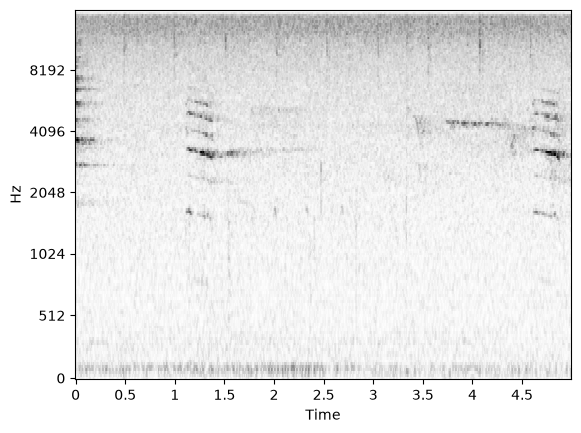

GridspecLayout(children=(Button(description='woothr', layout=Layout(grid_area='widget001'), style=ButtonStyle(…

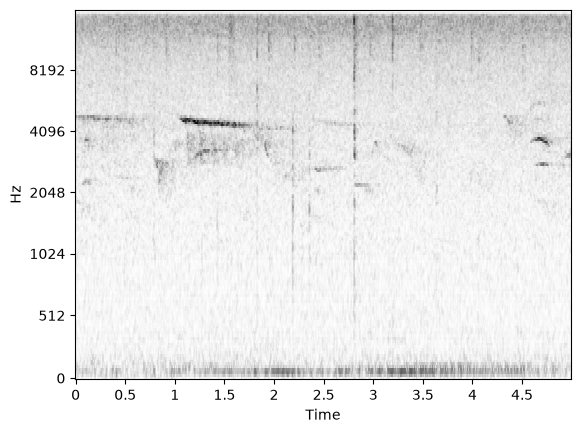

GridspecLayout(children=(Button(description='woothr', layout=Layout(grid_area='widget001'), style=ButtonStyle(…

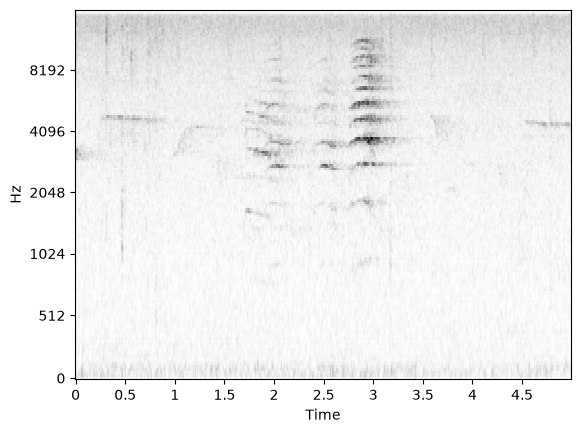

GridspecLayout(children=(Button(description='woothr', layout=Layout(grid_area='widget001'), style=ButtonStyle(…

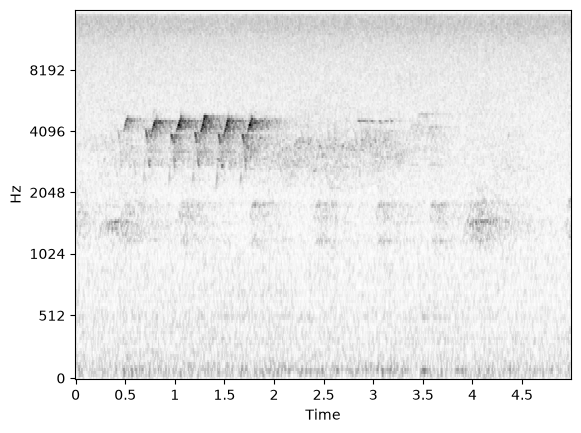

GridspecLayout(children=(Button(description='woothr', layout=Layout(grid_area='widget001'), style=ButtonStyle(…

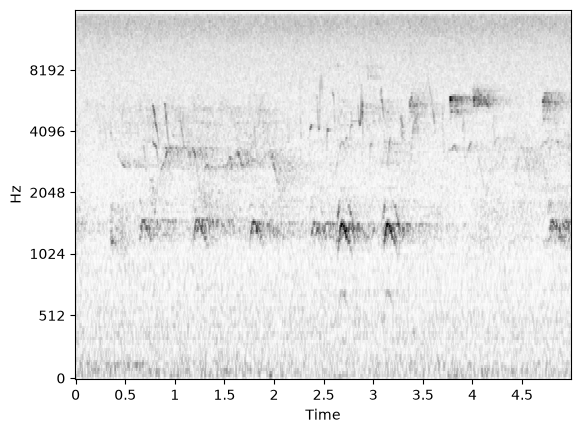

GridspecLayout(children=(Button(description='woothr', layout=Layout(grid_area='widget001'), style=ButtonStyle(…

Button(description='Prev Page', style=ButtonStyle())

Button(description='Next Page', style=ButtonStyle())

In [ ]:
# @title Display the search results for labeling {vertical-output: true}

display_results = embedding_display.EmbeddingDisplayGroup.from_search_results(
    results,
    db,
    sample_rate_hz=SAMPLE_RATE,
    frame_rate=100,
    audio_loader=audio_filepath_loader,
)
display_results.display(positive_labels=[target_label])

### Save your labels

This stores the labels you just applied in the database, tagged with your `annotator_id`, next to the embeddings they describe.

Run this **after** labeling the results above and **before** re-running the search — the widget is rebuilt each time you search, and any labels you have not saved are lost with it.

In [49]:
# @title Save the labels {vertical-output: true}

import collections

before = len(db.get_all_annotations())
new_labels = display_results.harvest_labels(annotator_id)

if not new_labels:
  print('NOTHING WAS SAVED - no results were labeled.\n')
  print('The label button cycles through four states as you click it:')
  print('    grey (no icon)  = unlabeled, ignored')
  print('    GREEN  (+)      = present   <-- click ONCE to get here')
  print('    orange (-)      = absent')
  print('    blue   (?)      = uncertain, deliberately skipped')
  print('    grey            = back to the start\n')
  print('Scroll up and click each button until it is GREEN with a + icon')
  print(f'on every clip where you hear the target species ({target_label}),')
  print('then run this cell again.\n')
  print('If none of the results genuinely contain the species, go back to')
  print('the search cell and try a different query window or a larger')
  print('num_results before labeling.')
else:
  db.insert_annotations(new_labels, handle_duplicates='skip')
  db.commit()
  after = len(db.get_all_annotations())

  kinds = collections.Counter(
      getattr(a.label_type, 'name', str(a.label_type)) for a in new_labels)
  print('Just labeled:')
  for kind, count in kinds.items():
    print(f'  {kind:10s} {count}')

  print(f'\nAnnotations before : {before}')
  print(f'Annotations after  : {after}')
  print(f'Newly saved        : {after - before}')

  print('\nTotal labels in the database:')
  for label, count in db.count_each_label().items():
    print(f'  {label:12s} {count}')

  n_target = db.count_each_label().get(target_label, 0)
  if n_target < 10:
    print(f'\nYou have {n_target} label(s) for {target_label}. Aim for at')
    print('least 10 before training. Re-run the search cell and label')
    print('another round - your saved labels are kept.')
  else:
    print(f'\n{n_target} labels for {target_label} - enough to train on.')

Just labeled:
  POSITIVE   2

Annotations before : 24
Annotations after  : 26
Newly saved        : 2

Total labels in the database:
  woothr       26

26 labels for woothr - enough to train on.


### <a name=choosing-target-score></a>Choosing a target score

The search also lets us look at how scores are distributed across the whole corpus. The actual numbers are hard to interpret on their own, but their *shape* is informative.

The histogram below samples scores from across the database. The bulk of it is everything that does **not** sound like your query — the ordinary background of the soundscape. Your search hits (red marks) sit out in the right tail.

Two regions of the histogram are useful, for different jobs:

* **The bulk** — everything that does not sound like your query. Set `target_score` inside the bulk (a low value) and the search returns clips that are almost all *not* the species: the fastest way to collect **negative labels**.
* **Where the tail meets the bulk** — the ambiguous cases: faint vocalizations, distant birds, calls partly masked by something else. Labeling these is worth far more per example than labeling more obvious hits, because they are what the decision boundary is actually made of.

**Try it:** read a value off the bulk, go back to the search cell, enable `target_sampling`, set `target_score` to that value, and label (and save) another round.

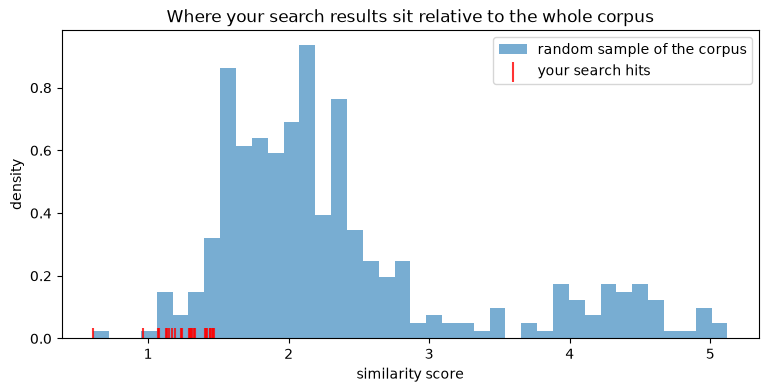

Corpus scores  : 0.61 to 5.12
Your hits      : 0.61 to 1.47


In [50]:
# @title Plot the distribution of scores {vertical-output: true}

scores = brutalism.get_random_embedding_scores(
    db,
    query_embedding,
    score_fn=score_functions.get_score_fn('dot'),
    sample_size=2048,
    rng_seed=42,
)

plt.figure(figsize=(9, 4))
plt.hist(scores, bins=40, density=True, alpha=0.6,
         label='random sample of the corpus')

hit_scores = [r.sort_score for r in results.search_results]
plt.scatter(hit_scores, np.zeros_like(hit_scores), marker='|',
            color='r', alpha=0.8, s=200, label='your search hits')

plt.xlabel('similarity score')
plt.ylabel('density')
plt.title('Where your search results sit relative to the whole corpus')
plt.legend()
plt.show()

print(f'Corpus scores  : {scores.min():.2f} to {scores.max():.2f}')
print(f'Your hits      : {min(hit_scores):.2f} to {max(hit_scores):.2f}')

<a name=active-learning></a>
## Train a Linear Classifier

In the last stage, we labeled samples from the search dataset as matches (by similarity comparison with the queries) for each of our target classes. We will now train a simple linear model using those bootstrapped (labeled) data points from the search dataset.

**Important:** in order to be able to train the linear model, we need ~10-12 examples from each class, in our case 'Wood Thrush' and 'Unknown'. If you encounter an error in this section when training the model, you likely did not generate a sufficient amount of labeled data. Please go back to the [Top-k Search](#top-k-search) section and choose a new value of the `target_score` attribute.

In [51]:
# @title Prepare the labeled data {vertical-output: true}

# Check that labels exist before doing anything else. Forgetting to click the
# label buttons, or forgetting to run the save cell, is the most common thing
# go wrong in this notebook - and the error it otherwise produces is useless.
existing_labels = db.get_all_labels()

if not existing_labels:
  raise ValueError(
      'No labels found in the database.\n\n'
      'The classifier has nothing to learn from. To create labels:\n'
      '  1. Scroll up and re-run the search cell.\n'
      '  2. In the results, CLICK THE LABEL BUTTON on every clip where\n'
      f'     you can hear the target species ({target_label}).\n'
      '  3. Run the "Save the labels" cell straight afterwards.\n'
      '  4. Repeat until you have at least 10 positives, then come back.\n\n'
      'Note: re-running the search cell discards any labels you have not\n'
      'saved yet, so save before searching again.'
  )

label_counts = db.count_each_label()
print('Labels in the database:')
for label, count in label_counts.items():
  print(f'  {label:12s} {count}')

n_target = label_counts.get(target_label, 0)
if n_target < 5:
  raise ValueError(
      f'Only {n_target} example(s) of {target_label!r} in the database.\n\n'
      'That is too few to split into training and evaluation sets. Go back\n'
      'to the search and labeling cells and collect at least 10 positives.'
  )

# @markdown Fraction of labeled examples used for training; the rest are held
# @markdown out to evaluate the model. With ~10 positives, 0.8 holds out two
# @markdown of them - the minimum this library needs to compute every metric.
train_ratio = 0.8  # @param {type: 'number'}

# @markdown Batch sizes for training and for weak negatives.
batch_size = 128  # @param {type: 'number'}
weak_negatives_batch_size = 128  # @param {type: 'number'}

data_manager = classifier_data.AgileDataManager(
    target_labels=None,  # auto-populated from the labels in the database
    db=db,
    train_ratio=train_ratio,
    min_eval_examples=1,
    batch_size=batch_size,
    weak_negatives_batch_size=weak_negatives_batch_size,
    rng=np.random.default_rng(seed=5),
)

print('\nTraining for target labels:', data_manager.get_target_labels())
train_ids, eval_ids = data_manager.get_train_test_split()
print(f'Training examples : {len(train_ids)}')
print(f'Held-out examples : {len(eval_ids)}')

if n_target < 10:
  print(f'\nWARNING: {n_target} positive example(s) is on the low side. The '
        'model will train, but the metrics below will be unstable - a single '
        'clip can swing them substantially. Treat them as a rough signal, not '
        'a measurement.')

Labels in the database:
  woothr       26

Training for target labels: ('woothr',)
Training examples : 45
Held-out examples : 10


### Train a simple linear model using the labeled embeddings

We use the following hyperparameters which should serve as reasonably performing defaults to train this linear model (classifier):

- `batch_size`: 12
- `num_epochs`: 128
- `num_hiddens`: -1 (to match the dimens of the embeddings)
- `learning_rate`: 0.001

Additionally, we compute the following metrics to measure the "goodness" of the trained model:
- `acc`: overall accuracy
- `auc_roc`: AUC ROC, or area under the receiving curve
- `cmAP`: mean average precision averaged across species
- `maps`: mean average precision for each class

In [52]:
# @title Classifier hyperparameters {vertical-output: true}

# @markdown These defaults work well and should not need tuning.
learning_rate = 1e-3  # @param {type: 'number'}
num_train_steps = 128  # @param {type: 'number'}

# @markdown How much to trust unlabeled results as negatives. Low by design:
# @markdown an unlabeled result is a guess, not an observation.
weak_neg_weight = 0.05  # @param {type: 'number'}

print(f'learning rate    : {learning_rate}')
print(f'training steps   : {num_train_steps}')
print(f'weak neg weight  : {weak_neg_weight}')

learning rate    : 0.001
training steps   : 128
weak neg weight  : 0.05


In [53]:
# @title Train the linear classifier {vertical-output: true}

linear_classifier, eval_scores = classifier.train_linear_classifier(
    data_manager=data_manager,
    learning_rate=learning_rate,
    weak_neg_weight=weak_neg_weight,
    num_train_steps=num_train_steps,
)

print('\nTraining complete.')

Loss 0.06920236: 100%|██████████| 128/128 [00:01<00:00, 68.88it/s]


Training complete.


#### Model performance

Three numbers are reported:

* **top-1 accuracy** — how often the highest-scoring label is correct.
* **ROC-AUC** — the probability that a randomly chosen positive scores higher than a randomly chosen negative. 0.5 is a coin flip; 1.0 is perfect.
* **cMAP** — mean average precision averaged over classes; sensitive to how well the positives are ranked.

**Read these with suspicion.** They are computed on held-out examples drawn from the data *you labeled*, and you found that data by searching for things similar to your query and labeling what you recognised. That is not a random sample of the soundscape — it is enriched for clear examples of one species, and it contains almost nothing from the long, dull stretches that make up most real recordings.

So a ROC-AUC of 0.95 here does **not** mean "95% reliable in the field." It means the classifier separates the kinds of examples you chose to show it. Performance on the full corpus is normally worse, sometimes much worse.

This is not a flaw in this tutorial — it is the standard failure mode of active learning, and knowing it exists is a large part of using these methods responsibly. We measure the real gap against expert ground truth further down.

In [54]:
# @title Show the metrics {vertical-output: true}

import math


def _fmt(value):
  """Format a metric, making 'could not be computed' explicit."""
  if value is None or (isinstance(value, float) and math.isnan(value)):
    return 'not computable'
  return f'{value:.3f}'


top1 = eval_scores['top1_acc']
rocauc = eval_scores['roc_auc']
cmap = eval_scores['cmap']

print(f'top-1 accuracy : {_fmt(top1)}')
print(f'ROC-AUC        : {_fmt(rocauc)}')
print(f'cMAP           : {_fmt(cmap)}')

print('\nLabels used for training:')
for label, count in db.count_each_label().items():
  print(f'  {label:12s} {count}')

def _is_nan(v):
  return v is None or (isinstance(v, float) and math.isnan(v))


if all(_is_nan(v) for v in (top1, rocauc, cmap)):
  print('\n' + '=' * 68)
  print('THE METRICS COULD NOT BE COMPUTED')
  print('=' * 68)
  print('Nothing crashed, and the model did train. But the evaluation')
  print('split did not contain both a positive and a negative example,')
  print('so there is nothing to measure the model against.\n')
  print('This matters more than it might appear. A model you cannot')
  print('evaluate is a model you cannot trust, however confident its')
  print('outputs look - and the cells below will happily produce')
  print('detections regardless. Do not believe them yet.\n')
  print('Fix: return to the search and labeling steps, collect at least')
  print('10 positive AND 10 negative labels, and retrain.')
else:
  if _is_nan(cmap):
    print('\nAbout the blank cMAP: this library only computes it when')
    print('the held-out split contains at least TWO positive clips;')
    print('yours holds fewer, so cMAP is skipped. The top-1 and ROC-AUC')
    print('numbers above are still valid. To get cMAP too, label a few')
    print('more positives, or lower train_ratio in the "Prepare the')
    print('labeled data" cell, and retrain.')
  if not _is_nan(rocauc):
    if rocauc < 0.9:
      print(f'\nROC-AUC is {rocauc:.3f}, below the 0.9 rule of thumb.')
      print('Before concluding the method does not work, try: labeling')
      print('more examples, enabling target sampling to find harder')
      print('cases, or choosing a cleaner query window.')
    else:
      print(f'\nROC-AUC of {rocauc:.3f} looks healthy - but read the')
      print('note above about why this number flatters the model.')

# Save the classifier so it can be reused without retraining.
classifier_path = os.path.join(db_path, 'agile_classifier.pt')
linear_classifier.save(classifier_path)
print(f'\nClassifier saved to {classifier_path}')

top-1 accuracy : 1.000
ROC-AUC        : 1.000
cMAP           : 1.000

Labels used for training:
  woothr       26

ROC-AUC of 1.000 looks healthy - but read the
note above about why this number flatters the model.

Classifier saved to ./powdermill_db/agile_classifier.pt


In [55]:
print(db.count_each_label())

Counter({'woothr': 26})


### The Active Learning Loop: Generating more training examples

It is possible, and even likely, that your first pass through the data yielded a model that could be improved, possibly with a low AUC-ROC, or poor performance in one particular class.  To improve the model, we need to generate additional interesting labeled examples from each class.  There are two ways we can proceed:

1. Go back to the audio search step and either use a new query example (if you have one), or play with the `target_score` param in the top-k search cell.
2. Now that we have trained a linear model, we can examine that model's outputs to help us surface new examples from th search corpus.

Both methods are perfectly reasonable, there is no right answer here!  If you'd like try the second method, proceed to the next cell.

### Generate new samples using logit scores

Most models output some notion of 'activation' per class, which can be thought of as some form of confidence score.  When you run a new sample through a model, the resulting activation value is called is a **logit**.  In the next cell we will surface new examples by looking for points in the search corpus that yield high logit scores for a given target class.  Intuitively, these are points that our linear model is very excited about, and therefore the resulting points are likely to be relevant to our task.

This method is similar to our top-k search method above.  We can input a `target_logit`, which will be used to surface points with a logit score that is close to the `target_logit`.  In a later cell, we show a histogram of all logit scores to indicate what the useful values of `target_logit` might be.  The first time through this cell, set `target_logit = None` to find matches with the highest logit.

Another good choice is `target_logit = 0.0`. This corresponds to the data where the model is most uncertain - labeling this data is a common active learning strategy called **margin sampling** and can help produce good models quickly.




In [56]:
# @title Find new examples using the classifier {vertical-output: true}

# @markdown Number of results to surface.
num_results = 25  # @param {type: 'number'}

# @markdown If checked, look for examples the model is *uncertain* about
# @markdown (margin sampling) rather than the ones it is most confident about.
margin_sampling = True  # @param {type: 'boolean'}

# @markdown The logit to aim for when margin sampling. 0.0 is the decision
# @markdown boundary - where the model is maximally unsure.
margin_target_score = 0.0  # @param {type: 'number'}

# @markdown How many database entries to search over.
sample_size = 1_000_000  # @param {type: 'number'}

target_label_idx = data_manager.get_target_labels().index(target_label)
class_query = linear_classifier.beta[:, target_label_idx]
bias = linear_classifier.beta_bias[target_label_idx]

score_fn = score_functions.get_score_fn(
    'dot', bias=bias,
    target_score=margin_target_score if margin_sampling else None)

results = brutalism.threaded_brute_search(
    db, class_query, num_results, score_fn=score_fn, sample_size=sample_size)

print(f'Returned {len(results.search_results)} results.')
print('Now label these below, then retrain. This is the active learning loop.')

Returned 25 results.
Now label these below, then retrain. This is the active learning loop.


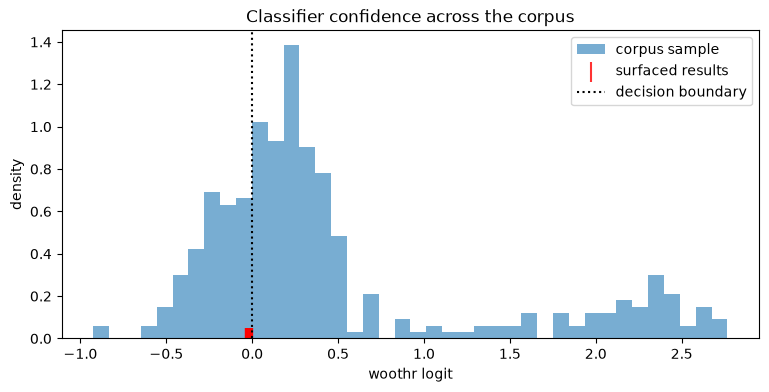

72.5% of sampled windows score above the decision boundary.
If that number looks implausibly high for one species in one forest, it probably is - a useful early warning of a poor classifier.


In [57]:
# @title Plot the classifier logits {vertical-output: true}

scores = brutalism.get_random_embedding_scores(
    db,
    class_query,
    score_fn=score_functions.get_score_fn('dot', bias=bias),
    sample_size=2048,
    rng_seed=42,
)

plt.figure(figsize=(9, 4))
plt.hist(scores, bins=40, density=True, alpha=0.6, label='corpus sample')

hit_scores = [r.sort_score for r in results.search_results]
plt.scatter(hit_scores, np.zeros_like(hit_scores), marker='|',
            color='r', alpha=0.8, s=200, label='surfaced results')
plt.axvline(0.0, color='k', linestyle=':', label='decision boundary')

plt.xlabel(f'{target_label} logit')
plt.ylabel('density')
plt.title('Classifier confidence across the corpus')
plt.legend()
plt.show()

above = (scores > 0).mean()
print(f'{above * 100:.1f}% of sampled windows score above the decision '
      'boundary.')
print('If that number looks implausibly high for one species in one forest, '
      'it probably is - a useful early warning of a poor classifier.')

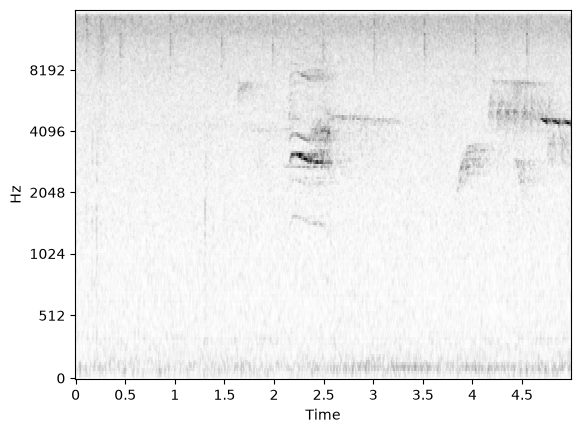

GridspecLayout(children=(Button(button_style='success', description='woothr', icon='plus-circle', layout=Layou…

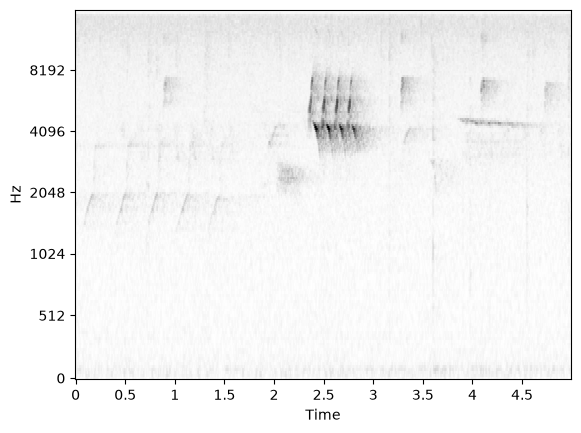

GridspecLayout(children=(Button(button_style='success', description='woothr', icon='plus-circle', layout=Layou…

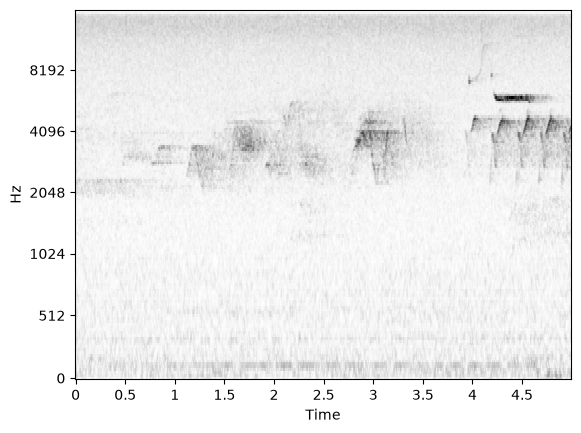

GridspecLayout(children=(Button(description='woothr', layout=Layout(grid_area='widget001'), style=ButtonStyle(…

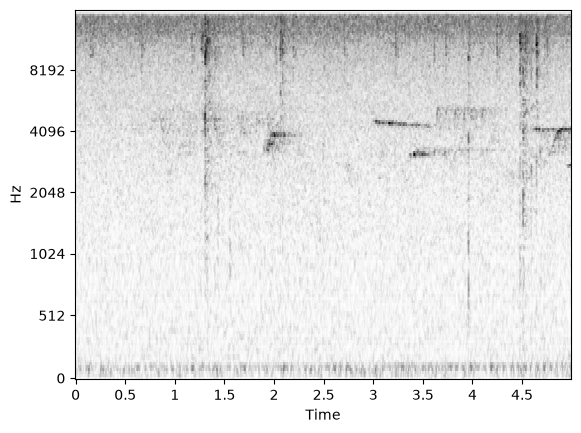

GridspecLayout(children=(Button(description='woothr', layout=Layout(grid_area='widget001'), style=ButtonStyle(…

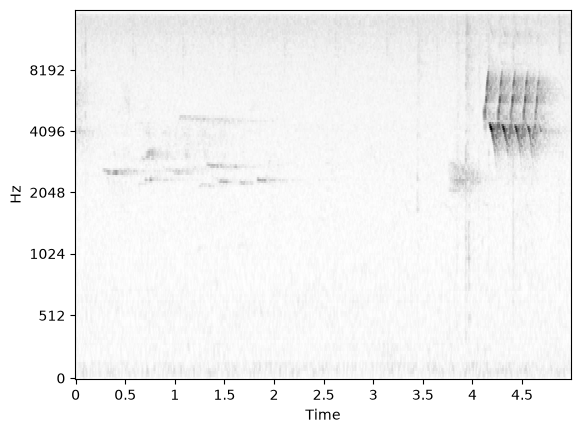

GridspecLayout(children=(Button(button_style='success', description='woothr', icon='plus-circle', layout=Layou…

Button(description='Prev Page', style=ButtonStyle())

Button(description='Next Page', style=ButtonStyle())

In [ ]:
# @title Display the new results for labeling {vertical-output: true}

display_results = embedding_display.EmbeddingDisplayGroup.from_search_results(
    results,
    db,
    sample_rate_hz=SAMPLE_RATE,
    frame_rate=100,
    audio_loader=audio_filepath_loader,
)
display_results.display(positive_labels=[target_label])

#### Add selected results to the labeled data

As before, once we've annotated the examples from the previous cell, we'll save them in the `labeled_data_dir`.

In [59]:
# @title Save the new labels {vertical-output: true}

print('Annotations before saving :', len(db.get_all_annotations()))

db.insert_annotations(
    display_results.harvest_labels(annotator_id),
    handle_duplicates='skip',
)
db.commit()

print('Annotations after saving  :', len(db.get_all_annotations()))
print('\nNow go back and retrain the classifier with this extra data.')

Annotations before saving : 26
Annotations after saving  : 35

Now go back and retrain the classifier with this extra data.


### Repeat!

We now have two distinct methods for generating training data.  Keep looping through those two methods and training new linear models until you have a model you're happy with (a high AUC-ROC score is a good indicator of model quality).

**Note:** to start completely fresh, delete the database folder (`/content/powdermill_db`) and re-run the notebook from the *Connect to the embedding database* cell — the database holds both the embeddings and every label you have saved.

### Write the detections to CSV

The point of building the classifier is to apply it to far more audio than anyone could listen to. This cell runs it over the whole embedding database and writes every detection above `logit_threshold` to a CSV.

**`logit_threshold` is the most consequential number in this notebook, and it is not a technical choice — it is a decision about what kind of mistake you would rather make.**

* A **low** threshold catches more real vocalizations (high recall) and admits more false alarms. Right when the cost of missing something is high and every detection will be checked by a human: screening for a rare or endangered species, or looking for the first arrival of an invasive one.
* A **high** threshold means most detections are genuine (high precision) but you miss the quiet and distant ones. Right when detections feed directly into a number nobody will verify by hand: an occupancy estimate, a population trend, a habitat comparison across sites.

There is no universally correct value. `1.0` is a starting point, not an answer. In a real programme you would choose it by labeling a random sample of detections, measuring the precision and recall you actually get at several thresholds, and picking the trade-off that matches the decision the output will feed.

Notice what that implies: **you cannot choose a threshold without knowing what the results are for.** A model handed over without that context is not finished, however good its ROC-AUC.

In [61]:
# @title Run inference over the whole corpus {vertical-output: true}

# @markdown Where to write the detections.
output_csv_filepath = './inference.csv'  # @param {type: 'string'}

# @markdown Minimum logit to record. See the discussion above - this is a
# @markdown decision about false positives versus missed detections.
logit_threshold = 1.0  # @param {type: 'number'}

classifier.write_inference_csv(
    linear_classifier,
    db,
    output_csv_filepath,
    logit_threshold,
    labels=None,
    window_ids=db.match_window_ids(),
)

import pandas as pd
detections = pd.read_csv(output_csv_filepath)
print(f'\nWrote {len(detections)} detections to {output_csv_filepath}')
print(f'That is {len(detections)} windows out of {db.count_embeddings()} '
      f'({100 * len(detections) / max(db.count_embeddings(), 1):.1f}% of the '
      'corpus).')
detections.head(10)

1it [00:00, 136.85it/s]

Wrote 67 detections to ./inference.csv

Wrote 67 detections to ./inference.csv
That is 67 windows out of 360 (18.6% of the corpus).


,idx,project,filename,window_start,window_end,label,logits
0,35,powdermill,Recording_2/Recording_2_Segment_13.wav,170.0,175.0,woothr,1.005368
1,39,powdermill,Recording_2/Recording_2_Segment_13.wav,190.0,195.0,woothr,1.265783
2,44,powdermill,Recording_2/Recording_2_Segment_13.wav,215.0,220.0,woothr,1.049382
3,46,powdermill,Recording_2/Recording_2_Segment_13.wav,225.0,230.0,woothr,1.078512
4,58,powdermill,Recording_2/Recording_2_Segment_13.wav,285.0,290.0,woothr,1.365102
5,60,powdermill,Recording_2/Recording_2_Segment_13.wav,295.0,300.0,woothr,1.328760
6,61,powdermill,Recording_2/Recording_2_Segment_01.wav,0.0,5.0,woothr,2.418808
7,62,powdermill,Recording_2/Recording_2_Segment_01.wav,5.0,10.0,woothr,2.164670
8,63,powdermill,Recording_2/Recording_2_Segment_01.wav,10.0,15.0,woothr,2.449257
9,64,powdermill,Recording_2/Recording_2_Segment_01.wav,15.0,20.0,woothr,2.129806


## Visualization of results

We will now use [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) to produce a scatter plot of all of the embeddings.
t-SNE is a technique for reducing high-dimensional data to two dimensions
for visualization. It tries to keep points which are close in the embedding
space close in the two-dimensional space.

We will also use the output probabilities from the classifier to color the
resulting scatter plot.

Projecting 360 embeddings of dimension 1280 down to 2D...


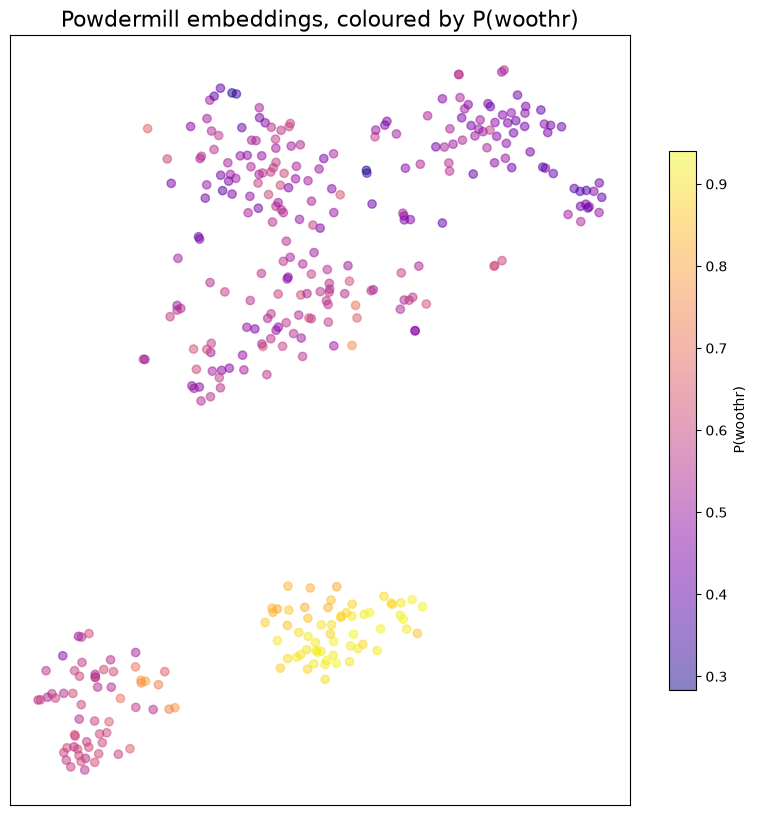

Each point is five seconds of audio. Points that sit near each other sound similar to the model.
If the classifier is working, the bright points should form clusters rather than being scattered at random.


In [62]:
# @title Visualize the embedding space {vertical-output: true}

import sklearn.decomposition
from sklearn.manifold import TSNE

window_ids = db.match_window_ids()
all_embeddings = db.get_embeddings_batch(window_ids)
all_logits = linear_classifier(all_embeddings)
target_logits = all_logits[:, target_label_idx]

print(f'Projecting {all_embeddings.shape[0]} embeddings of dimension '
      f'{all_embeddings.shape[1]} down to 2D...')

# PCA first (fast, keeps most of the variance), then t-SNE for the layout.
n_components = min(256, all_embeddings.shape[0] - 1, all_embeddings.shape[1])
reduced = sklearn.decomposition.PCA(n_components).fit_transform(all_embeddings)
projected = TSNE(perplexity=min(30, max(5, len(reduced) // 4))).fit_transform(
    reduced)


def sigmoid(x):
  return 1 / (1 + np.exp(-x))


plt.figure(figsize=(10, 10))
plt.title(f'Powdermill embeddings, coloured by P({target_label})', fontsize=16)
plt.xticks([])
plt.yticks([])
scatter = plt.scatter(projected[:, 0], projected[:, 1],
                      c=sigmoid(target_logits), cmap='plasma',
                      alpha=0.5, marker='o')
plt.colorbar(scatter, label=f'P({target_label})', shrink=0.7)
plt.show()

print('Each point is five seconds of audio. Points that sit near each other '
      'sound similar to the model.')
print('If the classifier is working, the bright points should form clusters '
      'rather than being scattered at random.')

<a name="discussion"></a>
# Discussion

This pipeline provides end-to-end annotation of a large unlabeled dataset based on a particular class (in our case, a species) of interest. To recap, we processed an unlabeled soundscape dataset through user-in-the-loop active learning to produce windowed annotations, and concluded by writing the annotated data to CSV. This allows for a variety of downstream analysis and visualization.

## From a working model to an ecological decision

You now have a classifier. It is worth being precise about what that does and does not entitle you to conclude, because the gap between "the model works" and "we should act on this" is where most applied ML in conservation actually fails.

### Who uses this, and for what

The output of this workflow — timestamped detections with confidence scores — feeds four broad kinds of decision, and each demands something different from the model.

| Use case | Who uses it | What they need from the model | What "good enough" looks like |
| --- | --- | --- | --- |
| **Species presence** — is this species here at all? | Reserve managers, environmental consultants, regulators | High recall. A missed detection means concluding a species is absent when it is not. | Every positive detection verified by a human. Precision matters less because the volume is small and the cost of checking is low. |
| **Population monitoring** — is it becoming more or less common? | Ecologists, long-term monitoring programmes | Stable, *calibrated* detection rates over time. | Consistency matters more than accuracy. A model that misses 30% of calls is usable for trends **if** it misses the same 30% every year. One that drifts is not. |
| **Habitat disturbance** — did logging, a road, or a fire change the soundscape? | Land managers, impact assessors | Comparable performance across sites and conditions. | The model must not perform differently in the disturbed and control sites for reasons unrelated to the birds — different background noise alone can produce a fake effect. |
| **Conservation action** — halt work, change protection status, direct funding | Agencies, NGOs, landowners | Defensible, auditable evidence. | Human verification of the detections the decision rests on, documented methods, and known error rates. A confidence score is not evidence. |

Notice that **no single accuracy number answers "is this good enough?"** The same classifier can be entirely adequate for directing a field team's attention and entirely inadequate for a regulatory filing. The question is never "is the model accurate" but "is the model accurate enough *for this decision*, given what happens if it is wrong."

### What happens if it is wrong

Both errors carry real costs, and they are not symmetrical:

* **False negatives** — the species is present but not detected. A site is cleared for development on the strength of a survey that missed the birds. This is the error that quietly does harm, because nobody ever finds out.
* **False positives** — the species is reported where it is absent. Protection is applied to the wrong parcel, monitoring effort is misdirected, and if it is later discovered, the credibility of the whole monitoring programme takes the damage — including its correct results.

Which one you should tolerate is a question for the people who bear the consequences, not for the person tuning the threshold. That conversation belongs at the start of a project, not after the model is built.

### What this tutorial has not shown you

The workflow here takes you from one example recording to a working classifier in under an hour. That is genuinely useful, and it is genuinely not a deployment. Before any of the decisions above, you would still need to:

1. **Validate on a random sample**, not on your search results. Take a random selection of windows from the corpus, label them blind, and measure precision and recall there. This is the single most important step, and the one most often skipped.
2. **Test on data from somewhere else** — a different site, a different season, a different recorder — to find out whether performance survives the move.
3. **Have a domain expert review the detections.** Not all of them; a sample large enough to estimate the error rate.
4. **Write down the error rates** alongside any number you report. A detection count without an error rate is not a measurement.
5. **Decide who checks the model over time**, and how often. Models do not degrade visibly.

## Limitations

This method works well across a wide range of bioacoustic signals — see [Feature Embeddings from Large-Scale Acoustic Bird Classifiers Enable Few-Shot Transfer Learning](https://arxiv.org/abs/2307.06292). But it has real limits, and several of them are invisible from inside this notebook.

### Limits of this tutorial specifically

**We used 30 minutes of audio, not 6.4 hours.** A subset chosen to keep the tutorial fast. Real surveys are orders of magnitude larger, and the rare events that matter most are precisely the ones a subset is likely to omit.

**Your evaluation set is not a random sample.** This is the most important caveat here. You found your training data by searching for clips similar to your query and labeling what you recognised. The held-out examples come from that same enriched pool. The reported ROC-AUC therefore measures how well the model separates *the kinds of clips you chose to look at* — not how it behaves on the long, quiet, ordinary stretches that make up most of a soundscape. **Field performance is normally worse, sometimes considerably.**

**One species, one site, two recording days, one season.** Nothing here tests whether any of it generalises.

### Limits that persist in real deployments

**Noisy field recordings.** Rain, wind, insects, traffic, aircraft, and rubbing vegetation all degrade detection, and they do so unevenly — a recorder near a stream is quietly handicapped for its whole deployment. Distance matters too: a bird 50 metres away produces a fainter, more distorted signal than the same bird at 5 metres, and the model sees these as meaningfully different sounds.

**Class imbalance.** In a typical soundscape the target species is present in well under 1% of windows. At that base rate, a classifier with 99% precision on a balanced test set can still return mostly false positives in the field. This is not a flaw in the model — it is what conditional probability does at low prevalence, and it surprises people constantly.

**Rare species.** The species most worth monitoring are usually the ones with the fewest recordings, and this workflow needs at least one good example to search with. For the rarest species that recording may not exist, may be poor quality, or may capture only one of several call types. Agile modeling reduces how much labeled data you need; it does not reduce it to zero.

**Geographic transferability.** Regional dialects are real in many songbirds, and a model tuned on Pennsylvania Wood Thrushes may perform worse elsewhere in the range. Background soundscapes differ too — a classifier that learned to separate its target from *this* forest's noise has partly learned the noise.

**Seasonal and temporal variation.** Powdermill is dawn chorus in breeding season, when birds sing most and most distinctively. The same species is quieter, and sings differently or not at all, outside that window. Juveniles sound different from adults. A model built on spring dawn recordings should not be assumed to work in autumn, at midday, or at night.

**Train/deployment mismatch.** The embedding model was trained largely on Xeno-Canto **focal** recordings — someone pointing a directional microphone at a single bird, close, clear, deliberately captured. Your corpus is **passive** monitoring: an omnidirectional recorder strapped to a tree, capturing everything at once. The transfer works well, which is the point of the paper above, but it is a genuine domain shift and it is where quiet or overlapping calls are lost.

**Recorder and settings differences.** Different hardware, gain settings, sample rates, and compression all shift the input. A model validated on one recorder type has not been validated on another.

**Annotator variation.** Your labels reflect your ear, your care, and your tolerance for uncertainty on the day. Two annotators rarely agree completely, and a model trained on one person's labels inherits that person's biases. This is why every annotation here is stored with an `annotator_id`.

### When to use a different approach

If performance stays poor after several rounds of labeling, the problem is often the **representation, not the classifier**. Try a different embedding model — `perch-hoplite` also ships BirdNET, Perch 2.0, and SurfPerch (reef sounds) presets. Note that embeddings from different models are not comparable, so switching means starting a fresh database (`db_path`) and re-embedding the audio from the setup section onward. For very noisy audio, [unsupervised sound separation](https://arxiv.org/abs/2110.03209) as a preprocessing step can improve retrieval substantially.

## Responsible use

**What this workflow is for:** helping experts search large volumes of audio far faster than they could by listening, and building custom detectors for sounds that no off-the-shelf classifier covers.

**What it is not for:**

* **Producing detection counts nobody verifies.** The output is a set of candidates with confidence scores. Treating it as a census is the most common misuse of this class of tool.
* **Regulatory or legal claims without expert review.** "The model found no Wood Thrush" is not evidence of absence, and should never be presented as such in an impact assessment.
* **Comparing sites or years without checking that the model behaves the same in each.** Apparent ecological differences are often model artefacts.
* **Monitoring humans.** These recorders capture speech. See below.

### Privacy

Passive acoustic monitors record whatever is audible, including human conversation. In many jurisdictions that carries legal obligations, and it carries ethical ones everywhere. Recordings from populated or publicly accessible areas need a retention policy, access controls, and — where people may reasonably expect privacy — consent or signage. This is a real and frequently overlooked consideration in bioacoustic programmes, not a hypothetical.

### Data sovereignty

Bioacoustic monitoring often happens on Indigenous or community-managed land. Who owns the recordings, who may access them, and who decides what is published are questions to settle before deployment, not after. Species-occurrence data can be sensitive in its own right: publishing precise locations of a rare species has, in documented cases, aided poachers and collectors.

### Being honest about uncertainty

The tool offers an "uncertain" label and then discards those clips rather than guessing. That design choice is worth carrying into your own practice. An annotation set that records genuine doubt as doubt is more useful than one where every hesitation has been quietly resolved into a yes or a no — and a model trained on the latter will confidently reproduce judgements nobody actually made.

### Documentation as a responsibility

If detections from a model like this inform a decision, someone should be able to reconstruct later how those detections were produced: which model, which query, who labeled the training data, what threshold, and what the measured error rates were. The datasheet and model card below are a starting template for that record.

## Next Directions

If you would like to apply these methods to your own audio dataset, the tools here should provide enough guidance to get started! For large datasets, you will want to use a GPU to compute the embeddings. And for very large datasets, we provide tooling for processing audio into embeddings with Apache Beam + Dataflow on GCP.


If you would like to try a different embedding model, our main codebase provides tools to do so. We provide an abstract EmbeddingModel class, which allows us to use any model that can turn a window of audio into an embedding.


There are a wide variety of problems to consider in this space!

* Detection of specific call types for a species,
* Classifying adult/juvenile calls,
* Tracking changes in vocalization patterns over time and geography,
* Tracking the impact of anthropogenic noise on an ecosystem,
* Broad biodiversity measurements,
* Directly classifying 'ecosystem health' from audio samples.

And more! Really, the only limit is your imagination!


## Datasheet: the datasets used

Following the structure proposed in [Datasheets for Datasets](https://arxiv.org/abs/1803.09010).

### Powdermill Nature Reserve soundscapes (the search corpus)

| Field | Detail |
| --- | --- |
| **Purpose** | Published to support development and evaluation of bird sound detection in passive recordings. |
| **Contents** | ~6.4 hours of dawn chorus soundscape audio from Powdermill Nature Reserve, Pennsylvania, USA, in four recording days, with expert annotations. This tutorial uses 30 minutes blended from two recording days (one song-dense and one sparse file from Recording_2, four Wood-Thrush-free files from Recording_4), chosen with the expert annotations so that high similarity scores correspond to real songs and low scores to genuine absence. |
| **Collection** | Passive acoustic monitoring — fixed omnidirectional recorders, capturing everything audible. Not targeted at individual birds. |
| **Annotations** | Expert-labeled with species, time, and frequency bounds. Supplied as Raven selection tables and a consolidated CSV. |
| **Licence** | CC-0 (public domain). |
| **Source** | [Zenodo record 4656848](https://zenodo.org/record/4656848); mirrored at `gs://chirp-public-bucket/soundscapes/powdermill`. |
| **Citation** | Chronister, L. M., Rhinehart, T. A., Place, A., & Kitzes, J. (2021). *An annotated set of audio recordings of Eastern North American birds containing frequency, time, and species information.* |
| **Known limitations** | A single site, a single season, dawn chorus only, temperate Eastern North American species. Not representative of tropical, nocturnal, marine, or arid soundscapes. Species distribution is heavily imbalanced. |
| **Preprocessing here** | Resampled to 32 kHz, split into non-overlapping 5-second windows. Only a subset is used, for speed. |
| **Sensitive content** | Passive recordings from a nature reserve. Human speech is possible in principle; none is used here. |

### Xeno-Canto (used to train the embedding model, and for the query)

| Field | Detail |
| --- | --- |
| **Purpose** | A community-contributed archive of wildlife sound recordings from around the world. |
| **Contents** | Hundreds of thousands of **focal** recordings — a recordist deliberately capturing a single identified bird. |
| **Collection** | Volunteer contributions, varying equipment, technique, and conditions. |
| **Licence** | Per-recording Creative Commons variants. Check individual recordings before redistribution. |
| **Source** | [xeno-canto.org](https://xeno-canto.org/) |
| **Known limitations** | **Strong geographic and species bias** toward regions with many active recordists — Europe and North America are far better covered than the tropics, where biodiversity is greatest. Focal recordings differ systematically from passive monitoring audio: closer, cleaner, higher signal-to-noise, and the target species is nearly always present. Species identifications are contributor-supplied and occasionally wrong. |
| **Role here** | The embedding model was pre-trained on this data. The query clip (`xc105133`) also comes from it. |

## Model card

Following the structure proposed in [Model Cards for Model Reporting](https://arxiv.org/abs/1810.03993). Two models are involved.

### 1. Perch / Bird Vocalization Classifier v8 (the embedding model)

| Field | Detail |
| --- | --- |
| **Developer** | Google DeepMind / Google Research (Perch team) |
| **Version** | `perch_8` — version 8 on Kaggle Models |
| **Input** | 5 seconds of audio at 32 kHz |
| **Output** | A 1280-dimensional embedding, plus species logits (unused here) |
| **Training data** | Xeno-Canto focal recordings, ~10,000 bird species |
| **Intended use** | A general-purpose representation for bioacoustic tasks, especially few-shot transfer |
| **Use here** | Feature extractor only. We never use its species predictions — we use its learned representation. |
| **Performance** | Embeddings transfer effectively to novel bioacoustic problems including call types, bats, and marine mammals, outperforming general audio models ([arXiv:2307.06292](https://arxiv.org/abs/2307.06292)) |
| **Limitations** | Trained on birds — non-bird sounds are further out of distribution. Focal-to-passive domain shift. Species coverage follows Xeno-Canto's geographic bias, so tropical species are less well represented. |
| **Licence** | See the [Kaggle model page](https://www.kaggle.com/models/google/bird-vocalization-classifier) |

### 2. The linear classifier you trained

| Field | Detail |
| --- | --- |
| **Developer** | You, in this notebook |
| **Architecture** | A single linear layer over 1280-dimensional embeddings |
| **Training data** | The handful of examples you labeled — typically 10–30 windows |
| **Training procedure** | 128 steps, learning rate 1e-3, binary cross-entropy, unlabeled search results treated as weak negatives at weight 0.05 |
| **Intended use** | **Demonstration and exploratory search within this corpus only.** |
| **Out of scope** | Any use outside this notebook without revalidation. Not suitable for population estimates, regulatory filings, or any decision affecting land use or protection status. |
| **Evaluation** | Held-out examples from the labeled pool. **This overstates field performance** — see Limitations. |
| **Ethical considerations** | Trained on one person's labels in one session. Inherits that annotator's biases and any errors in the query recording's identification. |
| **Caveats** | Performance depends heavily on the query window chosen, and on how carefully the labeling was done. Two participants following this notebook will produce measurably different classifiers. |

### Provenance recorded automatically

Every annotation is stored with its `annotator_id`, and the embedding configuration is stored inside the database. If detections from this model were ever questioned, that record is what would let someone reconstruct how they were produced.

# References

Perch [opensourced codebase](https://github.com/google-research/perch)

Open-sourced Datasets:
*    [Xeno-Canto](https://xeno-canto.org/)
*    [Powdermill Soundscape dataset](https://zenodo.org/record/4656848#.Y7ijhOxudhE)

Pre-trained embedding model for other transfer learning tasks:
*    [Bird Vocalization Classifier v4](https://tfhub.dev/google/bird-vocalization-classifier/4)

Related research:
* "Feature Embeddings from Large-Scale Acoustic Bird Classifiers Enable Few-Shot Transfer Learning" ([arXiv](https://arxiv.org/abs/2307.06292))
* "Agile Modeling: From Concept to Classifier in Minutes" ([arXiv](https://arxiv.org/abs/2302.12948))